# Sparse Octree Ablation Lab

Quick notebook for experimenting with the lowercase sparse-root model in `voxel_tree.tasks.sparse_octree`.

Focus:
- fast ablations on a subset
- holdout metrics the GUI does not currently show well
- easy tuning of `hidden`, `model_variant`, `split_weight`, and `label_weight`

Primary success signals:
- `split_f1`
- `split_under_rate`
- `leaf_acc`
- `leaf_node_ratio`

In [60]:
from __future__ import annotations

import csv
import importlib
import json
import math
import random
import sys
from dataclasses import dataclass, asdict
from datetime import datetime
from pathlib import Path
from typing import Any

import numpy as np
import torch
import yaml
from torch.utils.data import DataLoader, Subset


def find_repo_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in [start] + list(start.parents):
        if (candidate / 'pyproject.toml').exists() and (candidate / 'voxel_tree').exists():
            return candidate
    raise RuntimeError(f'Could not locate VoxelTree repo from {start}')


ROOT = find_repo_root(Path.cwd())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from voxel_tree.tasks.sparse_octree import sparse_octree as sparse_octree_mod
from voxel_tree.tasks.sparse_octree import sparse_octree_targets as sparse_octree_targets_mod
from voxel_tree.tasks.sparse_octree import sparse_octree_train as sparse_octree_train_mod

sparse_octree_mod = importlib.reload(sparse_octree_mod)
sparse_octree_targets_mod = importlib.reload(sparse_octree_targets_mod)
sparse_octree_train_mod = importlib.reload(sparse_octree_train_mod)

SparseOctreeDataset = sparse_octree_train_mod.SparseOctreeDataset
_build_model = sparse_octree_train_mod._build_model
_default_level_weights = sparse_octree_train_mod._default_level_weights
_finalize_metrics = sparse_octree_train_mod._finalize_metrics
_sparse_octree_loss = sparse_octree_train_mod._sparse_octree_loss
_update_batch_metrics = sparse_octree_train_mod._update_batch_metrics
sparse_octree_collate = sparse_octree_train_mod.sparse_octree_collate
build_sparse_octree_targets = sparse_octree_targets_mod.build_sparse_octree_targets
iter_sparse_octree_nodes = sparse_octree_targets_mod.iter_sparse_octree_nodes

PROFILE_PATH = ROOT / 'profiles' / 'new_profile.yaml'
PROFILE = yaml.safe_load(PROFILE_PATH.read_text(encoding='utf-8'))
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

print(f'ROOT      : {ROOT}')
print(f'PROFILE   : {PROFILE_PATH.name}')
print(f'DEVICE    : {DEVICE}')

ROOT      : C:\Users\JeffHall\git\MC\VoxelTree
PROFILE   : new_profile.yaml
DEVICE    : cpu


In [32]:
DATA_PATH = ROOT / PROFILE['data']['v7_pairs_npz']
OUTPUT_DIR = ROOT / 'runs' / 'notebook_sparse_octree_ablation'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DEFAULTS = {
    'epochs': 2,
    'batch_size': PROFILE['train'].get('batch_size', 4),
    'lr': PROFILE['train'].get('lr', 1e-4),
    'hidden': PROFILE['train'].get('sparse_octree_hidden', 80),
    'model_variant': PROFILE['train'].get('sparse_octree_variant', 'fast'),
    'split_weight': 1.0,
    'label_weight': 0.35,
    'label_smoothing': 0.03,
    'max_samples': 512,
    'holdout_fraction': 0.1,
    'seed': 7,
    'num_classes': 1104,
    'cache_targets': True,
}

for key, value in DEFAULTS.items():
    print(f'{key:>16}: {value}')
print(f'       data_path: {DATA_PATH}')
print(f'      output_dir: {OUTPUT_DIR}')

          epochs: 2
      batch_size: 8
              lr: 0.0001
          hidden: 80
   model_variant: fast
    split_weight: 1.0
    label_weight: 0.35
 label_smoothing: 0.03
     max_samples: 512
holdout_fraction: 0.1
            seed: 7
     num_classes: 1104
   cache_targets: True
       data_path: C:\Users\JeffHall\git\MC\VoxelTree\noise_training_data\sparse_octree_pairs_v7.npz
      output_dir: C:\Users\JeffHall\git\MC\VoxelTree\runs\notebook_sparse_octree_ablation


In [33]:
def inspect_npz(npz_path: Path) -> dict[str, Any]:
    npz = np.load(npz_path)
    summary: dict[str, Any] = {'path': str(npz_path), 'keys': list(npz.keys())}
    for key in npz.keys():
        arr = npz[key]
        summary[key] = {
            'shape': tuple(int(x) for x in arr.shape),
            'dtype': str(arr.dtype),
        }
    subchunk = npz['subchunk16']
    summary['num_samples'] = int(subchunk.shape[0])
    summary['air_fraction'] = float((subchunk == 0).mean())
    summary['max_block_id'] = int(subchunk.max())
    summary['noise_channels_3d'] = int(npz['noise_3d'].shape[1])
    summary['spatial_y'] = int(npz['noise_3d'].shape[3])
    summary['has_heightmaps'] = 'heightmap_surface' in npz and 'heightmap_ocean_floor' in npz
    return summary


def preview_targets(npz_path: Path, sample_idx: int = 0) -> dict[int, dict[str, Any]]:
    npz = np.load(npz_path)
    targets = build_sparse_octree_targets(npz['subchunk16'][sample_idx].astype(np.int32))
    max_level = max(targets)
    nodes = [
        node
        for node in iter_sparse_octree_nodes(targets, skip_empty_leaves=False)
        if node.is_leaf or node.child_mask != 0 or node.level == max_level
    ]
    out: dict[int, dict[str, Any]] = {}
    for node in nodes:
        bucket = out.setdefault(node.level, {'active_nodes': 0, 'leaf_nodes': 0, 'split_nodes': 0})
        bucket['active_nodes'] += 1
        if node.is_leaf:
            bucket['leaf_nodes'] += 1
        else:
            bucket['split_nodes'] += 1
    return out


NPZ_INFO = inspect_npz(DATA_PATH)
TARGET_INFO = preview_targets(DATA_PATH, sample_idx=0)
print(json.dumps(NPZ_INFO, indent=2))
print('--- target preview ---')
print(json.dumps(TARGET_INFO, indent=2))

{
  "path": "C:\\Users\\JeffHall\\git\\MC\\VoxelTree\\noise_training_data\\sparse_octree_pairs_v7.npz",
  "keys": [
    "subchunk16",
    "noise_3d",
    "biome_ids",
    "heightmap_surface",
    "heightmap_ocean_floor"
  ],
  "subchunk16": {
    "shape": [
      272,
      16,
      16,
      16
    ],
    "dtype": "int32"
  },
  "noise_3d": {
    "shape": [
      272,
      13,
      4,
      2,
      4
    ],
    "dtype": "float32"
  },
  "biome_ids": {
    "shape": [
      272,
      4,
      2,
      4
    ],
    "dtype": "int32"
  },
  "heightmap_surface": {
    "shape": [
      272,
      16,
      16
    ],
    "dtype": "int32"
  },
  "heightmap_ocean_floor": {
    "shape": [
      272,
      16,
      16
    ],
    "dtype": "int32"
  },
  "num_samples": 272,
  "air_fraction": 0.866572660558364,
  "max_block_id": 1082,
  "noise_channels_3d": 13,
  "spatial_y": 2,
  "has_heightmaps": true
}
--- target preview ---
{
  "4": {
    "active_nodes": 1,
    "leaf_nodes": 1,
    "split_

In [61]:
@dataclass
class ExperimentConfig:
    name: str
    epochs: int = DEFAULTS['epochs']
    batch_size: int = DEFAULTS['batch_size']
    lr: float = DEFAULTS['lr']
    hidden: int = DEFAULTS['hidden']
    model_variant: str = DEFAULTS['model_variant']
    split_weight: float = DEFAULTS['split_weight']
    label_weight: float = DEFAULTS['label_weight']
    label_smoothing: float = DEFAULTS['label_smoothing']
    max_samples: int | None = DEFAULTS['max_samples']
    holdout_fraction: float = DEFAULTS['holdout_fraction']
    seed: int = DEFAULTS['seed']
    num_classes: int = DEFAULTS['num_classes']
    cache_targets: bool = DEFAULTS['cache_targets']
    level_split_weights: dict[int, float] | None = None
    level_label_weights: dict[int, float] | None = None


def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def split_indices(n: int, holdout_fraction: float, seed: int, max_samples: int | None = None):
    rng = np.random.default_rng(seed)
    indices = np.arange(n)
    rng.shuffle(indices)
    if max_samples is not None:
        indices = indices[:max_samples]
    holdout_count = max(1, int(len(indices) * holdout_fraction))
    val_idx = indices[:holdout_count]
    train_idx = indices[holdout_count:]
    if len(train_idx) == 0:
        raise ValueError('Holdout split consumed all training samples')
    return train_idx.tolist(), val_idx.tolist()


def make_loader(dataset: SparseOctreeDataset, indices: list[int], batch_size: int, shuffle: bool) -> DataLoader:
    subset = Subset(dataset, indices)
    return DataLoader(subset, batch_size=batch_size, shuffle=shuffle, collate_fn=sparse_octree_collate)


def evaluate_model(
    model: torch.nn.Module,
    loader: DataLoader,
    device: str,
    *,
    split_weight: float,
    label_weight: float,
    label_smoothing: float,
    level_split_weights: dict[int, float] | None = None,
    level_label_weights: dict[int, float] | None = None,
    dynamic_split_pos_weight: bool = True,
    split_thresholds: dict[int, float] | None = None,
    default_split_threshold: float = 0.5,
) -> dict[str, float]:
    model.eval()
    total_loss = 0.0
    total_batches = 0
    metric_accum = {
        'split_tp': 0.0,
        'split_tn': 0.0,
        'split_fp': 0.0,
        'split_fn': 0.0,
        'leaf_correct': 0.0,
        'leaf_total': 0.0,
        'pred_leaf_nodes': 0.0,
        'gt_leaf_nodes': 0.0,
    }
    max_level = int(getattr(model, 'max_level', 4))
    default_level_split_weights, default_level_label_weights = _default_level_weights(max_level)
    merged_split_weights = dict(default_level_split_weights)
    merged_label_weights = dict(default_level_label_weights)
    if level_split_weights:
        merged_split_weights.update(level_split_weights)
    if level_label_weights:
        merged_label_weights.update(level_label_weights)

    with torch.no_grad():
        for batch in loader:
            noise_2d = batch['noise_2d'].to(device)
            noise_3d = batch['noise_3d'].to(device)
            biome_ids = batch['biome_ids'].to(device)
            heightmap_surface = batch['heightmap_surface'].to(device)
            heightmap_ocean_floor = batch['heightmap_ocean_floor'].to(device)
            preds = model(
                noise_2d,
                noise_3d,
                biome_ids,
                heightmap_surface,
                heightmap_ocean_floor,
            )
            loss = _sparse_octree_loss(
                preds,
                batch['targets'],
                split_weight=split_weight,
                label_weight=label_weight,
                level_split_weights=merged_split_weights,
                level_label_weights=merged_label_weights,
                label_smoothing=label_smoothing,
                dynamic_split_pos_weight=dynamic_split_pos_weight,
            )
            total_loss += float(loss.detach().cpu())
            total_batches += 1

            if split_thresholds:
                thresholded_preds: dict[int, dict[str, torch.Tensor]] = {}
                for lvl, out in preds.items():
                    threshold = float(split_thresholds.get(int(lvl), default_split_threshold))
                    threshold = min(max(threshold, 1e-6), 1.0 - 1e-6)
                    threshold_logit = math.log(threshold / (1.0 - threshold))
                    thresholded_preds[int(lvl)] = {
                        'split': (out['split'] > threshold_logit).float(),
                        'label': out['label'],
                    }
                _update_batch_metrics(thresholded_preds, batch['targets'], metric_accum)
            else:
                _update_batch_metrics(preds, batch['targets'], metric_accum)

    metrics = {'loss': total_loss / max(total_batches, 1)}
    metrics.update(_finalize_metrics(metric_accum))
    return metrics

In [62]:
def run_quick_experiment(config: ExperimentConfig, *, data_path: Path = DATA_PATH, output_dir: Path = OUTPUT_DIR, device: str = DEVICE) -> dict[str, Any]:
    set_seed(config.seed)
    dataset = SparseOctreeDataset(data_path, cache_targets=config.cache_targets)
    train_idx, val_idx = split_indices(
        len(dataset),
        holdout_fraction=config.holdout_fraction,
        seed=config.seed,
        max_samples=config.max_samples,
    )
    train_loader = make_loader(dataset, train_idx, config.batch_size, shuffle=True)
    val_loader = make_loader(dataset, val_idx, config.batch_size, shuffle=False)

    sample = dataset[train_idx[0]]
    model = _build_model(
        config.model_variant,
        n2d=int(sample['noise_2d'].shape[0]),
        n3d=int(sample['noise_3d'].shape[0]),
        hidden=config.hidden,
        num_classes=config.num_classes,
        spatial_y=int(dataset.spatial_y),
    ).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=config.lr)
    max_level = int(getattr(model, 'max_level', 4))
    default_level_split_weights, default_level_label_weights = _default_level_weights(max_level)
    level_split_weights = dict(default_level_split_weights)
    level_label_weights = dict(default_level_label_weights)
    if config.level_split_weights:
        level_split_weights.update(config.level_split_weights)
    if config.level_label_weights:
        level_label_weights.update(config.level_label_weights)

    best_val_loss = float('inf')
    best_epoch = -1
    best_state = None
    best_val_metrics = None
    history: list[dict[str, float]] = []

    for epoch in range(1, config.epochs + 1):
        model.train()
        total_loss = 0.0
        total_batches = 0
        metric_accum = {
            'split_tp': 0.0,
            'split_tn': 0.0,
            'split_fp': 0.0,
            'split_fn': 0.0,
            'leaf_correct': 0.0,
            'leaf_total': 0.0,
            'pred_leaf_nodes': 0.0,
            'gt_leaf_nodes': 0.0,
        }
        for batch in train_loader:
            noise_2d = batch['noise_2d'].to(device)
            noise_3d = batch['noise_3d'].to(device)
            biome_ids = batch['biome_ids'].to(device)
            heightmap_surface = batch['heightmap_surface'].to(device)
            heightmap_ocean_floor = batch['heightmap_ocean_floor'].to(device)
            optimizer.zero_grad()
            preds = model(
                noise_2d,
                noise_3d,
                biome_ids,
                heightmap_surface,
                heightmap_ocean_floor,
            )
            loss = _sparse_octree_loss(
                preds,
                batch['targets'],
                split_weight=config.split_weight,
                label_weight=config.label_weight,
                level_split_weights=level_split_weights,
                level_label_weights=level_label_weights,
                label_smoothing=config.label_smoothing,
                dynamic_split_pos_weight=True,
            )
            loss.backward()
            optimizer.step()
            total_loss += float(loss.detach().cpu())
            total_batches += 1
            _update_batch_metrics(preds, batch['targets'], metric_accum)

        train_metrics = {'loss': total_loss / max(total_batches, 1)}
        train_metrics.update(_finalize_metrics(metric_accum))
        val_metrics = evaluate_model(
            model,
            val_loader,
            device,
            split_weight=config.split_weight,
            label_weight=config.label_weight,
            label_smoothing=config.label_smoothing,
            level_split_weights=level_split_weights,
            level_label_weights=level_label_weights,
        )

        row = {'epoch': float(epoch)}
        row.update({f'train_{k}': float(v) for k, v in train_metrics.items()})
        row.update({f'val_{k}': float(v) for k, v in val_metrics.items()})
        history.append(row)

        if val_metrics['loss'] < best_val_loss:
            best_val_loss = float(val_metrics['loss'])
            best_epoch = epoch
            best_val_metrics = dict(val_metrics)
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    checkpoint_path = output_dir / f'{config.name}.pt'
    checkpoint_path.parent.mkdir(parents=True, exist_ok=True)
    torch.save(best_state if best_state is not None else model.state_dict(), checkpoint_path)

    return {
        'name': config.name,
        'config': asdict(config),
        'checkpoint': str(checkpoint_path),
        'train_samples': len(train_idx),
        'val_samples': len(val_idx),
        'best_epoch': best_epoch,
        'best_val_loss': best_val_loss,
        'best_val_metrics': best_val_metrics,
        'history': history,
    }


def summarize_results(results: list[dict[str, Any]]) -> list[dict[str, Any]]:
    rows = []
    for item in results:
        metrics = item.get('best_val_metrics') or {}
        rows.append({
            'name': item['name'],
            'variant': item['config']['model_variant'],
            'hidden': item['config']['hidden'],
            'epochs': item['config']['epochs'],
            'best_epoch': item['best_epoch'],
            'val_loss': metrics.get('loss', item['best_val_loss']),
            'split_f1': metrics.get('split_f1'),
            'split_under_rate': metrics.get('split_under_rate'),
            'leaf_acc': metrics.get('leaf_acc'),
            'leaf_node_ratio': metrics.get('leaf_node_ratio'),
        })
    rows.sort(key=lambda row: (-(row['split_f1'] or -1.0), row['val_loss']))
    return rows


def save_results(results: list[dict[str, Any]], *, output_dir: Path = OUTPUT_DIR) -> tuple[Path, Path]:
    stamp = datetime.now().strftime('%Y%m%d_%H%M%S')
    json_path = output_dir / f'sparse_octree_experiments_{stamp}.json'
    csv_path = output_dir / f'sparse_octree_experiments_{stamp}.csv'
    json_path.write_text(json.dumps(results, indent=2), encoding='utf-8')
    rows = summarize_results(results)
    with csv_path.open('w', newline='', encoding='utf-8') as f:
        writer = csv.DictWriter(f, fieldnames=list(rows[0].keys()) if rows else ['name'])
        writer.writeheader()
        if rows:
            writer.writerows(rows)
    return json_path, csv_path

In [6]:
RUN_SMOKE = False

if RUN_SMOKE:
    smoke = ExperimentConfig(
        name='smoke_fast_h32',
        epochs=2,
        batch_size=4,
        hidden=32,
        model_variant='fast',
        max_samples=128,
    )
    smoke_result = run_quick_experiment(smoke)
    print(json.dumps({k: v for k, v in smoke_result.items() if k != 'history'}, indent=2))
else:
    print('Set RUN_SMOKE = True to run a quick subset experiment.')

Set RUN_SMOKE = True to run a quick subset experiment.


In [7]:
RUN_SWEEP = False

if RUN_SWEEP:
    experiments = [
        ExperimentConfig(name='fast_h32', hidden=32, model_variant='fast', max_samples=128, epochs=2),
        ExperimentConfig(name='fast_h64', hidden=64, model_variant='fast', max_samples=128, epochs=2),
        ExperimentConfig(name='baseline_h64', hidden=64, model_variant='baseline', max_samples=128, epochs=2),
        ExperimentConfig(name='fast_h64_more_label', hidden=64, model_variant='fast', label_weight=0.50, max_samples=128, epochs=2),
    ]
    sweep_results = [run_quick_experiment(exp) for exp in experiments]
    summary_rows = summarize_results(sweep_results)
    print(json.dumps(summary_rows, indent=2))
    json_path, csv_path = save_results(sweep_results)
    print(f'Saved: {json_path}')
    print(f'Saved: {csv_path}')
else:
    print('Set RUN_SWEEP = True to compare a few configs.')

Set RUN_SWEEP = True to compare a few configs.


## Structural improvement roadmap

The position-feature path has been retired from the model code. Use the notebook to explore higher-ROI improvements instead:
- per-level split-threshold tuning
- per-level loss reshaping (especially stronger coarse split penalties)
- difficulty-aware train/holdout splits
- checkpoint selection by structural score rather than raw validation loss

The threshold-analysis cells below still apply. The structural experiment cells near the bottom add training-side probes for these ideas.

In [8]:
RUN_STRUCTURAL_NOTES = False

if RUN_STRUCTURAL_NOTES:
    print('Use the structural experiment cells near the bottom of the notebook.')
    print('Recommended first comparisons: baseline vs coarse-split-upweight vs difficulty-stratified split.')
else:
    print('Position-feature ablations were retired. Scroll to the structural experiment section for the next round of ideas.')

Position-feature ablations were retired. Scroll to the structural experiment section for the next round of ideas.


In [63]:
def infer_sparse_checkpoint_config(state_dict: dict[str, torch.Tensor], sample: dict[str, Any], spatial_y: int) -> dict[str, Any]:
    is_fast = any(key.startswith('level_mod.') for key in state_dict)
    variant = 'fast' if is_fast else 'baseline'
    if is_fast:
        hidden = int(state_dict['root_proj.0.weight'].shape[0])
        num_classes = int(state_dict['label_head.out_proj.weight'].shape[0])
        input_dim = int(state_dict['noise_enc.mlp.0.weight'].shape[1])
    else:
        hidden = int(state_dict['root_proj.weight'].shape[0])
        num_classes = int(state_dict['label_head.weight'].shape[0])
        input_dim = int(state_dict['noise_enc.mlp.0.weight'].shape[1])

    flat_2d = int(sample['noise_2d'].shape[0]) * 4 * 4
    flat_3d = int(sample['noise_3d'].shape[0]) * 4 * int(spatial_y) * 4
    biome_embed_dim = 8
    flat_biome = 4 * int(spatial_y) * 4 * biome_embed_dim
    flat_heightmaps = 16 * 16 * 2
    base_input_dim = flat_2d + flat_3d + flat_biome + flat_heightmaps
    extra_input_dim = input_dim - base_input_dim
    if extra_input_dim != 0:
        raise ValueError(
            'Checkpoint input width does not match the current sparse-octree model. '
            f'Expected base_input_dim={base_input_dim}, found {input_dim}. '
            'This checkpoint likely depends on retired extra context features.'
        )

    return {
        'model_variant': variant,
        'hidden': hidden,
        'num_classes': num_classes,
        'n2d': int(sample['noise_2d'].shape[0]),
        'n3d': int(sample['noise_3d'].shape[0]),
        'spatial_y': int(spatial_y),
    }


def evaluate_existing_checkpoint(checkpoint_path: Path, *, data_path: Path = DATA_PATH, max_samples: int = 256, seed: int = 7) -> dict[str, Any]:
    dataset = SparseOctreeDataset(data_path, cache_targets=True)
    train_idx, val_idx = split_indices(len(dataset), holdout_fraction=0.1, seed=seed, max_samples=max_samples)
    val_loader = make_loader(dataset, val_idx, batch_size=DEFAULTS['batch_size'], shuffle=False)
    state_dict = torch.load(checkpoint_path, map_location='cpu', weights_only=False)
    if 'model_state_dict' in state_dict:
        state_dict = state_dict['model_state_dict']
    sample = dataset[train_idx[0]]
    cfg = infer_sparse_checkpoint_config(state_dict, sample, dataset.spatial_y)
    model = _build_model(
        cfg['model_variant'],
        n2d=cfg['n2d'],
        n3d=cfg['n3d'],
        hidden=cfg['hidden'],
        num_classes=cfg['num_classes'],
        spatial_y=cfg['spatial_y'],
    ).to(DEVICE)
    model.load_state_dict(state_dict)
    metrics = evaluate_model(model, val_loader, DEVICE, split_weight=1.0, label_weight=0.35, label_smoothing=0.03)
    return {'checkpoint': str(checkpoint_path), 'inferred': cfg, 'metrics': metrics}


PRIMARY_CHECKPOINT = ROOT / 'models' / 'new_profile' / 'sparse_octree_model.pt'
CHECKPOINT_CANDIDATES = [PRIMARY_CHECKPOINT]
for checkpoint in CHECKPOINT_CANDIDATES:
    print(checkpoint, 'exists=' + str(checkpoint.exists()))

# Example:
# report = evaluate_existing_checkpoint(PRIMARY_CHECKPOINT)
# print(json.dumps(report, indent=2))

C:\Users\JeffHall\git\MC\VoxelTree\models\new_profile\sparse_octree_model.pt exists=True


## Train fresh checkpoint

Train a model from scratch using the current architecture (per-level split bias, wider FiLM, L4/L0 split zeroed, clamped pos_weight). All downstream analysis cells use `PRIMARY_CHECKPOINT`.

In [64]:
# ── Train a fresh model from scratch ────────────────────────────────
# Uses the notebook's run_quick_experiment with 25 epochs, h80, fast variant.
# The resulting checkpoint replaces PRIMARY_CHECKPOINT for all downstream cells.

fresh_config = ExperimentConfig(
    name='calibration_fix_h80_e25',
    epochs=25,
    batch_size=8,
    hidden=80,
    model_variant='fast',
    max_samples=272,
    lr=1e-4,
)

print(f'Training {fresh_config.name} from scratch ...')
fresh_result = run_quick_experiment(fresh_config)

# ── Summary ────────────────────────────────────────────────────────
print(f"\nBest epoch: {fresh_result['best_epoch']}")
for k, v in (fresh_result.get('best_val_metrics') or {}).items():
    print(f"  {k}: {v:.4f}")

# Update PRIMARY_CHECKPOINT so all downstream cells use the fresh model
import shutil
fresh_ckpt = Path(fresh_result['checkpoint'])
PRIMARY_CHECKPOINT.parent.mkdir(parents=True, exist_ok=True)
shutil.copy2(fresh_ckpt, PRIMARY_CHECKPOINT)
print(f"\nCopied to PRIMARY_CHECKPOINT: {PRIMARY_CHECKPOINT}")
CHECKPOINT_CANDIDATES = [PRIMARY_CHECKPOINT]

Training calibration_fix_h80_e25 from scratch ...

Best epoch: 25
  loss: 4.9779
  split_acc: 0.5934
  split_precision: 0.8890
  split_recall: 0.6176
  split_f1: 0.7288
  split_over_rate: 0.5922
  split_under_rate: 0.3824
  leaf_acc: 0.5306
  leaf_node_ratio: 3.3435
  split_f1_L4: 0.6500
  split_f1_L3: 0.7862
  split_f1_L2: 0.9519
  split_f1_L1: 0.9704
  split_f1_L0: 0.6835

Copied to PRIMARY_CHECKPOINT: C:\Users\JeffHall\git\MC\VoxelTree\models\new_profile\sparse_octree_model.pt


## Visualize results

Use these helpers after running `RUN_SMOKE` or `RUN_SWEEP`, or after saving experiment JSON files to the notebook output directory.

In [38]:
import matplotlib.pyplot as plt
import pandas as pd


def _latest_result_json(output_dir: Path = OUTPUT_DIR) -> Path | None:
    candidates = sorted(output_dir.glob('sparse_octree_experiments_*.json'))
    return candidates[-1] if candidates else None


def collect_results(output_dir: Path = OUTPUT_DIR) -> list[dict[str, Any]]:
    if 'sweep_results' in globals() and isinstance(sweep_results, list) and sweep_results:
        return sweep_results
    if 'smoke_result' in globals() and isinstance(smoke_result, dict):
        return [smoke_result]
    latest = _latest_result_json(output_dir)
    if latest is None:
        return []
    return json.loads(latest.read_text(encoding='utf-8'))


def results_frame(results: list[dict[str, Any]] | None = None) -> pd.DataFrame:
    results = collect_results() if results is None else results
    rows = summarize_results(results)
    if not rows:
        return pd.DataFrame(columns=['name', 'variant', 'hidden', 'epochs', 'best_epoch', 'val_loss', 'split_f1', 'split_under_rate', 'leaf_acc', 'leaf_node_ratio'])
    frame = pd.DataFrame(rows)
    preferred = [
        'name',
        'variant',
        'hidden',
        'epochs',
        'best_epoch',
        'val_loss',
        'split_f1',
        'split_under_rate',
        'leaf_acc',
        'leaf_node_ratio',
    ]
    return frame[preferred]


def plot_histories(results: list[dict[str, Any]] | None = None, metric: str = 'val_split_f1') -> None:
    results = collect_results() if results is None else results
    if not results:
        print('No results available yet. Run RUN_SMOKE / RUN_SWEEP or load saved JSON first.')
        return

    plt.figure(figsize=(9, 4.5))
    for result in results:
        history = result.get('history', [])
        if not history:
            continue
        epochs = [row['epoch'] for row in history if metric in row]
        values = [row[metric] for row in history if metric in row]
        if values:
            plt.plot(epochs, values, marker='o', label=result['name'])
    plt.xlabel('Epoch')
    plt.ylabel(metric)
    plt.title(f'Sparse octree ablations — {metric}')
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()


def plot_tradeoff(results: list[dict[str, Any]] | None = None) -> None:
    results = collect_results() if results is None else results
    frame = results_frame(results)
    if frame.empty:
        print('No results available yet.')
        return

    plt.figure(figsize=(6.5, 5))
    plt.scatter(frame['split_under_rate'], frame['split_f1'], s=80)
    for _, row in frame.iterrows():
        plt.annotate(row['name'], (row['split_under_rate'], row['split_f1']), xytext=(5, 5), textcoords='offset points')
    plt.axvline(0.05, color='tab:red', linestyle='--', alpha=0.7, label='target split_under_rate <= 0.05')
    plt.axhline(0.90, color='tab:green', linestyle='--', alpha=0.7, label='target split_f1 >= 0.90')
    plt.xlabel('split_under_rate')
    plt.ylabel('split_f1')
    plt.title('Tradeoff: missed splits vs structural F1')
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()


def show_results(results: list[dict[str, Any]] | None = None) -> pd.DataFrame:
    frame = results_frame(results)
    if frame.empty:
        print('No results available yet.')
        return frame
    display(frame.style.format({
        'val_loss': '{:.4f}',
        'split_f1': '{:.4f}',
        'split_under_rate': '{:.4f}',
        'leaf_acc': '{:.4f}',
        'leaf_node_ratio': '{:.4f}',
    }).background_gradient(subset=['split_f1', 'leaf_acc'], cmap='Greens').background_gradient(subset=['split_under_rate', 'val_loss'], cmap='Reds_r'))
    return frame


# Example:
# frame = show_results()
# plot_histories(metric='val_split_f1')
# plot_histories(metric='val_loss')
# plot_tradeoff()

## Sample browser

Use these helpers to inspect a single subchunk, its target tree, and a few horizontal slices. This is useful when aggregate metrics look odd and you want to see whether the model is failing on easy or pathological terrain.

In [39]:
def sample_summary(npz_path: Path, sample_idx: int) -> dict[str, Any]:
    npz = np.load(npz_path)
    subchunk = npz['subchunk16'][sample_idx].astype(np.int32)
    targets = build_sparse_octree_targets(subchunk)
    nodes = [
        node
        for node in iter_sparse_octree_nodes(targets, skip_empty_leaves=False)
        if node.is_leaf or node.child_mask != 0 or node.level == max(targets)
    ]
    level_counts: dict[int, dict[str, int]] = {}
    for node in nodes:
        bucket = level_counts.setdefault(node.level, {'active': 0, 'leaf': 0, 'split': 0})
        bucket['active'] += 1
        if node.is_leaf:
            bucket['leaf'] += 1
        else:
            bucket['split'] += 1
    return {
        'sample_idx': sample_idx,
        'air_fraction': float((subchunk == 0).mean()),
        'non_air_blocks': int((subchunk != 0).sum()),
        'unique_block_ids': int(np.unique(subchunk).size),
        'max_block_id': int(subchunk.max()),
        'levels': level_counts,
    }


def rank_samples(npz_path: Path = DATA_PATH, top_k: int = 12) -> pd.DataFrame:
    npz = np.load(npz_path)
    rows = []
    for sample_idx, subchunk in enumerate(npz['subchunk16']):
        subchunk = subchunk.astype(np.int32)
        air_fraction = float((subchunk == 0).mean())
        unique_blocks = int(np.unique(subchunk).size)
        non_air_blocks = int((subchunk != 0).sum())
        rows.append({
            'sample_idx': sample_idx,
            'air_fraction': air_fraction,
            'solid_fraction': 1.0 - air_fraction,
            'unique_block_ids': unique_blocks,
            'non_air_blocks': non_air_blocks,
        })
    frame = pd.DataFrame(rows)
    frame = frame.sort_values(['solid_fraction', 'unique_block_ids'], ascending=[False, False])
    return frame.head(top_k)


def plot_sample(npz_path: Path = DATA_PATH, sample_idx: int = 0, y_slices: tuple[int, ...] = (0, 4, 8, 12)) -> dict[str, Any]:
    npz = np.load(npz_path)
    subchunk = npz['subchunk16'][sample_idx].astype(np.int32)
    height_surface = npz['heightmap_surface'][sample_idx]
    height_ocean = npz['heightmap_ocean_floor'][sample_idx]

    summary = sample_summary(npz_path, sample_idx)
    print(json.dumps(summary, indent=2))

    fig, axes = plt.subplots(2, max(len(y_slices), 2), figsize=(3.5 * max(len(y_slices), 2), 7))
    axes = np.atleast_2d(axes)

    for col, y in enumerate(y_slices):
        ax = axes[0, col]
        im = ax.imshow(subchunk[y], cmap='tab20', interpolation='nearest')
        ax.set_title(f'block ids @ y={y}')
        ax.set_xlabel('x')
        ax.set_ylabel('z')
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    axes[1, 0].imshow(height_surface, cmap='terrain')
    axes[1, 0].set_title('heightmap_surface')
    axes[1, 0].set_xlabel('x')
    axes[1, 0].set_ylabel('z')

    axes[1, 1].imshow(height_ocean, cmap='terrain')
    axes[1, 1].set_title('heightmap_ocean_floor')
    axes[1, 1].set_xlabel('x')
    axes[1, 1].set_ylabel('z')

    for extra in range(2, axes.shape[1]):
        axes[1, extra].axis('off')

    plt.tight_layout()
    plt.show()
    return summary


# Example:
# rank_samples()
# plot_sample(sample_idx=0)
# plot_sample(sample_idx=int(rank_samples().iloc[0]['sample_idx']))

## Prediction vs target browser

Use an existing sparse-octree checkpoint to inspect where split decisions or leaf labels are going wrong on individual samples.

In [40]:
def load_sparse_checkpoint(checkpoint_path: Path, *, data_path: Path = DATA_PATH) -> tuple[torch.nn.Module, SparseOctreeDataset, dict[str, Any]]:
    dataset = SparseOctreeDataset(data_path, cache_targets=True)
    state = torch.load(checkpoint_path, map_location='cpu', weights_only=False)
    if 'model_state_dict' in state:
        state = state['model_state_dict']
    sample = dataset[0]
    cfg = infer_sparse_checkpoint_config(state, sample, dataset.spatial_y)
    model = _build_model(
        cfg['model_variant'],
        n2d=cfg['n2d'],
        n3d=cfg['n3d'],
        hidden=cfg['hidden'],
        num_classes=cfg['num_classes'],
        spatial_y=cfg['spatial_y'],
    ).to(DEVICE)
    model.load_state_dict(state)
    model.eval()
    return model, dataset, cfg


def _level_side(level: int, max_level: int = 4) -> int:
    return 2 ** (max_level - level)


def _reshape_level(values: np.ndarray, level: int, max_level: int = 4) -> np.ndarray:
    side = _level_side(level, max_level=max_level)
    return values.reshape(side, side, side)


def predict_sample(
    checkpoint_path: Path,
    *,
    sample_idx: int = 0,
    split_threshold: float = 0.5,
    data_path: Path = DATA_PATH,
) -> dict[str, Any]:
    model, dataset, cfg = load_sparse_checkpoint(checkpoint_path, data_path=data_path)
    sample = dataset[sample_idx]

    with torch.no_grad():
        preds = model(
            sample['noise_2d'].unsqueeze(0).to(DEVICE),
            sample['noise_3d'].unsqueeze(0).to(DEVICE),
            sample['biome_ids'].unsqueeze(0).to(DEVICE),
            sample['heightmap_surface'].unsqueeze(0).to(DEVICE),
            sample['heightmap_ocean_floor'].unsqueeze(0).to(DEVICE),
        )

    per_level: dict[int, dict[str, Any]] = {}
    max_level = int(getattr(model, 'max_level', 4))
    threshold_logit = math.log(split_threshold / (1.0 - split_threshold)) if 0.0 < split_threshold < 1.0 else 0.0

    for level, out in preds.items():
        split_logits = out['split'][0].detach().cpu()
        split_probs = torch.sigmoid(split_logits)
        split_pred = split_logits > threshold_logit

        target_split = sample['targets'][level]['split'] > 0.5
        target_label = sample['targets'][level]['label']
        gt_leaf_mask = sample['targets'][level]['is_leaf'].bool()
        label_pred = out['label'][0].detach().cpu().argmax(dim=-1)

        tp = int((split_pred & target_split).sum().item())
        tn = int(((~split_pred) & (~target_split)).sum().item())
        fp = int((split_pred & (~target_split)).sum().item())
        fn = int(((~split_pred) & target_split).sum().item())
        precision = tp / max(tp + fp, 1)
        recall = tp / max(tp + fn, 1)
        f1 = 2.0 * precision * recall / max(precision + recall, 1e-12)

        leaf_correct = torch.full_like(split_probs, float('nan'), dtype=torch.float32)
        if gt_leaf_mask.any():
            leaf_correct[gt_leaf_mask] = (label_pred[gt_leaf_mask] == target_label[gt_leaf_mask]).float()

        per_level[int(level)] = {
            'side': _level_side(int(level), max_level=max_level),
            'split_probs': _reshape_level(split_probs.numpy(), int(level), max_level=max_level),
            'split_pred': _reshape_level(split_pred.numpy().astype(np.float32), int(level), max_level=max_level),
            'split_target': _reshape_level(target_split.numpy().astype(np.float32), int(level), max_level=max_level),
            'leaf_correct': _reshape_level(leaf_correct.numpy(), int(level), max_level=max_level),
            'target_split_count': int(target_split.sum().item()),
            'pred_split_count': int(split_pred.sum().item()),
            'split_precision': precision,
            'split_recall': recall,
            'split_f1': f1,
            'split_over_rate': fp / max(fp + tn, 1),
            'split_under_rate': fn / max(fn + tp, 1),
            'leaf_acc_gt_only': float(torch.nanmean(leaf_correct).item()) if gt_leaf_mask.any() else float('nan'),
        }

    return {
        'checkpoint': str(checkpoint_path),
        'sample_idx': sample_idx,
        'split_threshold': split_threshold,
        'config': cfg,
        'summary': sample_summary(data_path, sample_idx),
        'per_level': per_level,
    }


def rank_checkpoint_failures(
    checkpoint_path: Path,
    *,
    data_path: Path = DATA_PATH,
    sample_indices: list[int] | None = None,
    top_k: int = 12,
    split_threshold: float = 0.5,
) -> pd.DataFrame:
    model, dataset, cfg = load_sparse_checkpoint(checkpoint_path, data_path=data_path)
    threshold_logit = math.log(split_threshold / (1.0 - split_threshold)) if 0.0 < split_threshold < 1.0 else 0.0

    if sample_indices is None:
        sample_indices = list(range(len(dataset)))

    rows: list[dict[str, Any]] = []
    with torch.no_grad():
        for sample_idx in sample_indices:
            sample = dataset[sample_idx]
            preds = model(
                sample['noise_2d'].unsqueeze(0).to(DEVICE),
                sample['noise_3d'].unsqueeze(0).to(DEVICE),
                sample['biome_ids'].unsqueeze(0).to(DEVICE),
                sample['heightmap_surface'].unsqueeze(0).to(DEVICE),
                sample['heightmap_ocean_floor'].unsqueeze(0).to(DEVICE),
            )
            metric_accum = {
                'split_tp': 0.0,
                'split_tn': 0.0,
                'split_fp': 0.0,
                'split_fn': 0.0,
                'leaf_correct': 0.0,
                'leaf_total': 0.0,
                'pred_leaf_nodes': 0.0,
                'gt_leaf_nodes': 0.0,
            }

            converted_preds: dict[int, dict[str, torch.Tensor]] = {}
            converted_targets: dict[int, dict[str, torch.Tensor]] = {}
            for level, out in preds.items():
                split_logits = out['split'][0].detach().cpu()
                split_pred = (split_logits > threshold_logit).float().unsqueeze(0)
                label_logits = out['label'][0].detach().cpu().unsqueeze(0)
                converted_preds[int(level)] = {'split': split_pred, 'label': label_logits}
                converted_targets[int(level)] = {
                    'split': sample['targets'][level]['split'].unsqueeze(0),
                    'label': sample['targets'][level]['label'].unsqueeze(0),
                    'is_leaf': sample['targets'][level]['is_leaf'].unsqueeze(0),
                }

            _update_batch_metrics(converted_preds, converted_targets, metric_accum)
            metrics = _finalize_metrics(metric_accum)
            rows.append({
                'sample_idx': sample_idx,
                'solid_fraction': 1.0 - float((dataset.subchunks[sample_idx] == 0).mean()),
                'split_f1': metrics['split_f1'],
                'split_under_rate': metrics['split_under_rate'],
                'split_over_rate': metrics['split_over_rate'],
                'leaf_acc': metrics['leaf_acc'],
                'leaf_node_ratio': metrics['leaf_node_ratio'],
                'variant': cfg['model_variant'],
                'hidden': cfg['hidden'],
            })

    frame = pd.DataFrame(rows)
    return frame.sort_values(['split_f1', 'split_under_rate', 'split_over_rate'], ascending=[True, False, False]).head(top_k)


def plot_prediction_browser(
    checkpoint_path: Path,
    *,
    sample_idx: int = 0,
    levels: tuple[int, ...] = (4, 3, 2, 1, 0),
    split_threshold: float = 0.5,
    data_path: Path = DATA_PATH,
) -> dict[str, Any]:
    report = predict_sample(
        checkpoint_path,
        sample_idx=sample_idx,
        split_threshold=split_threshold,
        data_path=data_path,
    )

    print(json.dumps(report['summary'], indent=2))

    fig, axes = plt.subplots(len(levels), 4, figsize=(14, 3.2 * len(levels)))
    if len(levels) == 1:
        axes = np.expand_dims(axes, axis=0)

    for row_idx, level in enumerate(levels):
        level_data = report['per_level'][level]
        target_split = level_data['split_target'].max(axis=0)
        pred_prob = level_data['split_probs'].mean(axis=0)
        pred_split = level_data['split_pred'].max(axis=0)
        leaf_correct_raw = level_data['leaf_correct']
        valid_leaf_counts = np.isfinite(leaf_correct_raw).sum(axis=0)
        leaf_correct = np.divide(
            np.nansum(leaf_correct_raw, axis=0),
            np.maximum(valid_leaf_counts, 1),
        )
        leaf_correct = leaf_correct.astype(np.float32)
        leaf_correct[valid_leaf_counts == 0] = np.nan

        images = [target_split, pred_prob, pred_split, leaf_correct]
        titles = [
            f'L{level} target split',
            f'L{level} pred split prob',
            f'L{level} pred split',
            f'L{level} leaf acc on gt leaves',
        ]
        cmaps = ['Blues', 'magma', 'Oranges', 'viridis']
        vmins = [0.0, 0.0, 0.0, 0.0]
        vmaxs = [1.0, 1.0, 1.0, 1.0]

        for col_idx, (img, title, cmap, vmin, vmax) in enumerate(zip(images, titles, cmaps, vmins, vmaxs)):
            ax = axes[row_idx, col_idx]
            shown = np.nan_to_num(img, nan=-0.05)
            im = ax.imshow(shown, cmap=cmap, vmin=vmin, vmax=vmax, interpolation='nearest')
            ax.set_title(title)
            ax.set_xlabel('x')
            ax.set_ylabel('z')
            fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

        metrics = {
            key: level_data[key]
            for key in ['target_split_count', 'pred_split_count', 'split_f1', 'split_under_rate', 'split_over_rate', 'leaf_acc_gt_only']
        }
        axes[row_idx, 0].text(
            0.02,
            -0.28,
            json.dumps(metrics, indent=2),
            transform=axes[row_idx, 0].transAxes,
            fontsize=8,
            va='top',
            family='monospace',
        )

    plt.tight_layout()
    plt.show()
    return report


# Example:
# failure_table = rank_checkpoint_failures(CHECKPOINT_CANDIDATES[0])
# display(failure_table)
# worst_idx = int(failure_table.iloc[0]['sample_idx'])
# report = plot_prediction_browser(CHECKPOINT_CANDIDATES[0], sample_idx=worst_idx, split_threshold=0.5)

In [41]:
failure_table = rank_checkpoint_failures(
    PRIMARY_CHECKPOINT,
    sample_indices=list(range(24)),
    top_k=8,
)
failure_table

,sample_idx,solid_fraction,split_f1,split_under_rate,split_over_rate,leaf_acc,leaf_node_ratio,variant,hidden
23,23,0.247803,0.907115,0.0,0.994994,0.782228,0.005006,fast,80
22,22,0.250000,0.908900,0.0,0.994904,0.797452,0.005096,fast,80
7,7,0.249512,0.910679,0.0,0.994812,0.802853,0.005188,fast,80
14,14,0.250000,0.911566,0.0,0.994764,0.807592,0.005236,fast,80
15,15,0.250000,0.912452,0.0,0.994716,0.809775,0.005284,fast,80
21,21,0.250000,0.912452,0.0,0.994716,0.776750,0.005284,fast,80
12,12,0.250000,0.913336,0.0,0.994667,0.809333,0.005333,fast,80
4,4,0.250000,0.914219,0.0,0.994616,0.815612,0.005384,fast,80


{
  "sample_idx": 23,
  "air_fraction": 0.752197265625,
  "non_air_blocks": 1015,
  "unique_block_ids": 18,
  "max_block_id": 982,
  "levels": {
    "4": {
      "active": 1,
      "leaf": 0,
      "split": 1
    },
    "3": {
      "active": 8,
      "leaf": 4,
      "split": 4
    },
    "2": {
      "active": 32,
      "leaf": 16,
      "split": 16
    },
    "1": {
      "active": 128,
      "leaf": 35,
      "split": 93
    },
    "0": {
      "active": 744,
      "leaf": 744,
      "split": 0
    }
  }
}


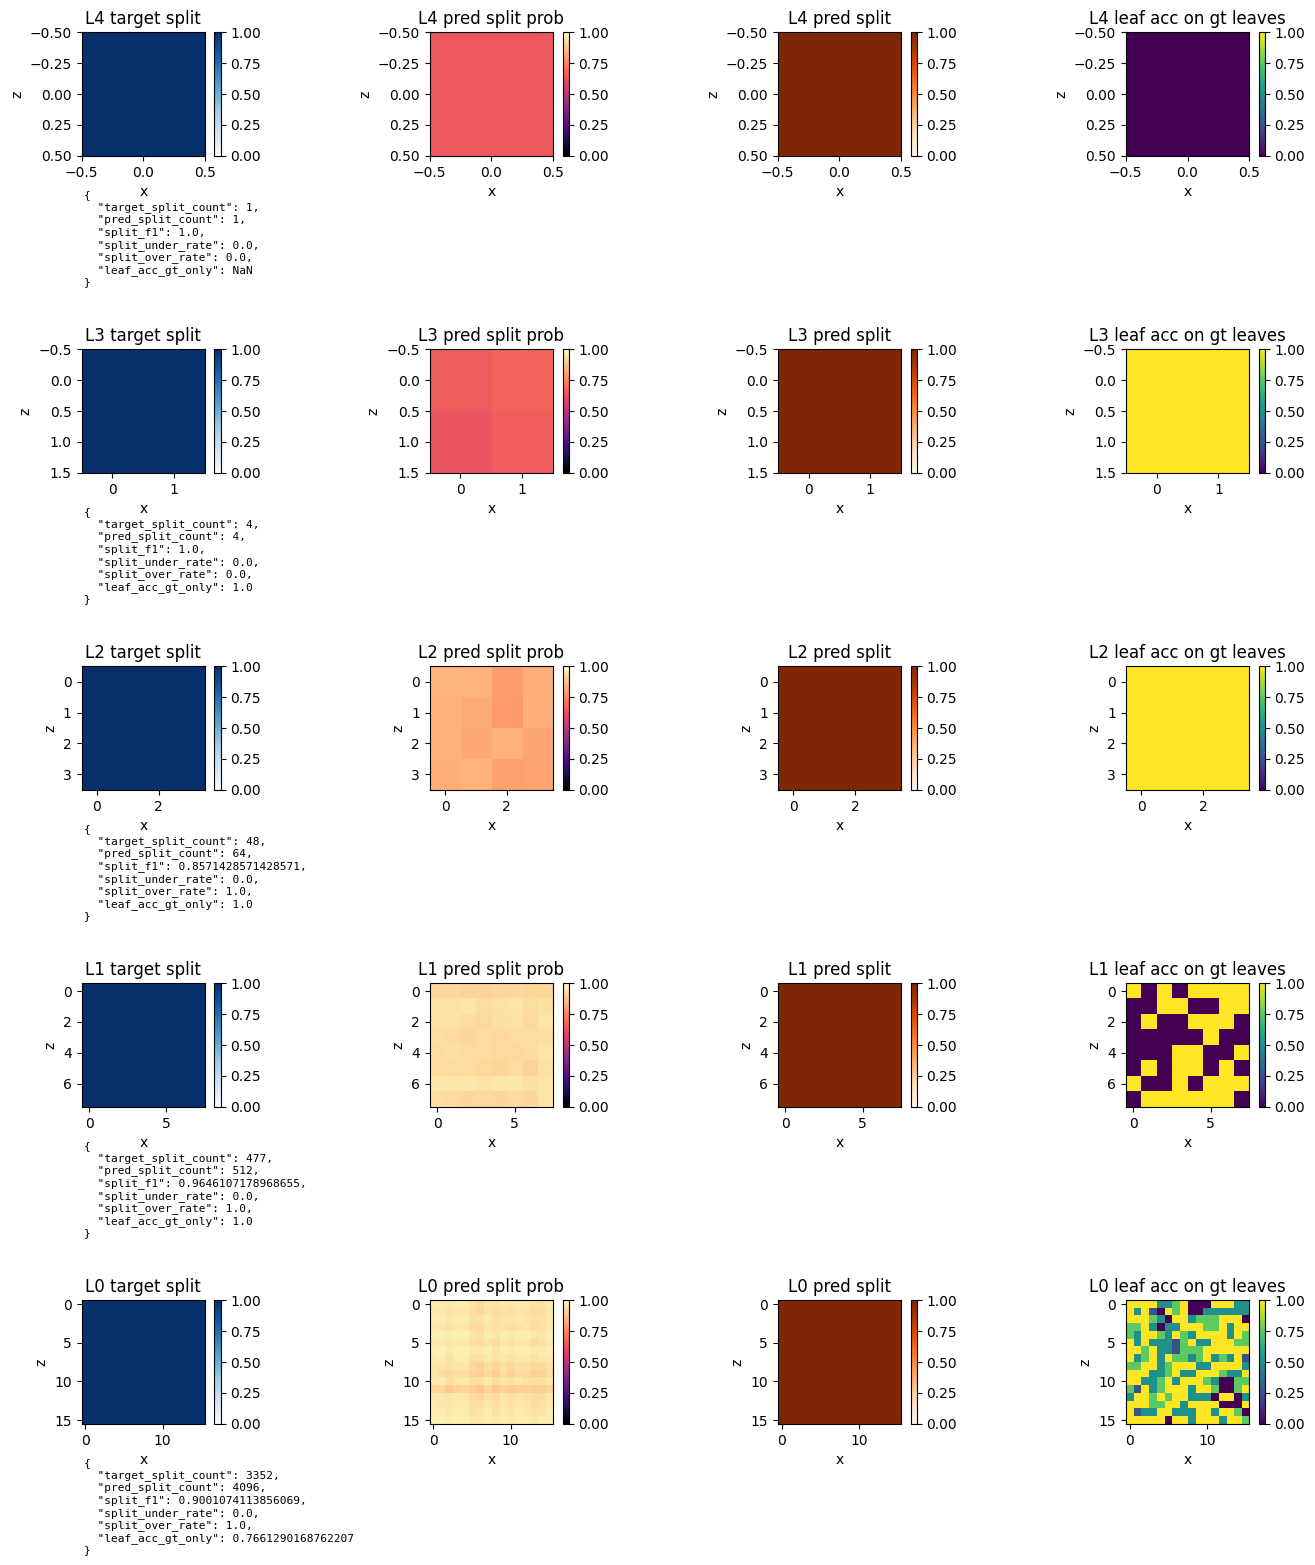

Plotted worst sample: 23


In [42]:
worst_idx = int(failure_table.iloc[0]['sample_idx'])
worst_report = plot_prediction_browser(
    PRIMARY_CHECKPOINT,
    sample_idx=worst_idx,
    split_threshold=0.5,
)
print(f'Plotted worst sample: {worst_idx}')

## Threshold sweep and level confusion

Use these helpers to answer two concrete questions:
- does a different global split threshold help?
- which octree levels are under-splitting or over-splitting the most?

In [43]:
def _threshold_to_logit(split_threshold: float) -> float:
    if split_threshold <= 0.0:
        return float('-inf')
    if split_threshold >= 1.0:
        return float('inf')
    return math.log(split_threshold / (1.0 - split_threshold))


def _sample_prediction_cache(
    checkpoint_path: Path,
    *,
    data_path: Path = DATA_PATH,
    sample_indices: list[int] | None = None,
) -> tuple[dict[str, Any], list[dict[str, Any]]]:
    model, dataset, cfg = load_sparse_checkpoint(checkpoint_path, data_path=data_path)
    if sample_indices is None:
        sample_indices = list(range(len(dataset)))

    cached: list[dict[str, Any]] = []
    with torch.no_grad():
        for sample_idx in sample_indices:
            sample = dataset[sample_idx]
            preds = model(
                sample['noise_2d'].unsqueeze(0).to(DEVICE),
                sample['noise_3d'].unsqueeze(0).to(DEVICE),
                sample['biome_ids'].unsqueeze(0).to(DEVICE),
                sample['heightmap_surface'].unsqueeze(0).to(DEVICE),
                sample['heightmap_ocean_floor'].unsqueeze(0).to(DEVICE),
            )
            per_level: dict[int, dict[str, torch.Tensor]] = {}
            for level, out in preds.items():
                per_level[int(level)] = {
                    'split_logits': out['split'][0].detach().cpu(),
                    'label_logits': out['label'][0].detach().cpu(),
                    'target_split': sample['targets'][level]['split'].detach().cpu(),
                    'target_label': sample['targets'][level]['label'].detach().cpu(),
                    'is_leaf': sample['targets'][level]['is_leaf'].detach().cpu(),
                }
            cached.append(
                {
                    'sample_idx': sample_idx,
                    'solid_fraction': 1.0 - float((dataset.subchunks[sample_idx] == 0).mean()),
                    'levels': per_level,
                }
            )
    return cfg, cached


def summarize_level_confusion(
    checkpoint_path: Path,
    *,
    split_threshold: float = 0.5,
    data_path: Path = DATA_PATH,
    sample_indices: list[int] | None = None,
) -> pd.DataFrame:
    cfg, cached = _sample_prediction_cache(
        checkpoint_path,
        data_path=data_path,
        sample_indices=sample_indices,
    )
    threshold_logit = _threshold_to_logit(split_threshold)

    rows: list[dict[str, Any]] = []
    levels = sorted(cached[0]['levels'].keys(), reverse=True) if cached else []
    for level in levels:
        tp = tn = fp = fn = 0.0
        leaf_correct = 0.0
        leaf_total = 0.0
        pred_leaf_nodes = 0.0
        gt_leaf_nodes = 0.0
        for item in cached:
            lvl = item['levels'][level]
            split_pred = lvl['split_logits'] > threshold_logit
            split_tgt = lvl['target_split'] > 0.5
            tp += float((split_pred & split_tgt).sum().item())
            tn += float(((~split_pred) & (~split_tgt)).sum().item())
            fp += float((split_pred & (~split_tgt)).sum().item())
            fn += float(((~split_pred) & split_tgt).sum().item())

            gt_leaf_mask = lvl['is_leaf'].bool()
            label_pred = lvl['label_logits'].argmax(dim=-1)
            if gt_leaf_mask.any():
                leaf_total += float(gt_leaf_mask.sum().item())
                leaf_correct += float((label_pred[gt_leaf_mask] == lvl['target_label'][gt_leaf_mask]).sum().item())
            pred_leaf_nodes += float((~split_pred).sum().item())
            gt_leaf_nodes += float((~split_tgt).sum().item())

        precision = tp / max(tp + fp, 1.0)
        recall = tp / max(tp + fn, 1.0)
        f1 = 2.0 * precision * recall / max(precision + recall, 1e-12)
        rows.append(
            {
                'level': level,
                'target_split_count': int(tp + fn),
                'pred_split_count': int(tp + fp),
                'split_precision': precision,
                'split_recall': recall,
                'split_f1': f1,
                'split_under_rate': fn / max(fn + tp, 1.0),
                'split_over_rate': fp / max(fp + tn, 1.0),
                'leaf_acc': leaf_correct / max(leaf_total, 1.0),
                'leaf_node_ratio': pred_leaf_nodes / max(gt_leaf_nodes, 1.0),
                'variant': cfg['model_variant'],
                'hidden': cfg['hidden'],
                'threshold': split_threshold,
            }
        )

    frame = pd.DataFrame(rows)
    return frame.sort_values('level', ascending=False)


def sweep_split_thresholds(
    checkpoint_path: Path,
    *,
    thresholds: list[float] | np.ndarray | None = None,
    data_path: Path = DATA_PATH,
    sample_indices: list[int] | None = None,
) -> pd.DataFrame:
    if thresholds is None:
        thresholds = np.linspace(0.1, 0.9, 17)
    cfg, cached = _sample_prediction_cache(
        checkpoint_path,
        data_path=data_path,
        sample_indices=sample_indices,
    )

    rows: list[dict[str, Any]] = []
    for threshold in thresholds:
        threshold_logit = _threshold_to_logit(float(threshold))
        metric_accum = {
            'split_tp': 0.0,
            'split_tn': 0.0,
            'split_fp': 0.0,
            'split_fn': 0.0,
            'leaf_correct': 0.0,
            'leaf_total': 0.0,
            'pred_leaf_nodes': 0.0,
            'gt_leaf_nodes': 0.0,
        }
        for item in cached:
            converted_preds: dict[int, dict[str, torch.Tensor]] = {}
            converted_targets: dict[int, dict[str, torch.Tensor]] = {}
            for level, lvl in item['levels'].items():
                split_pred = (lvl['split_logits'] > threshold_logit).float().unsqueeze(0)
                converted_preds[level] = {
                    'split': split_pred,
                    'label': lvl['label_logits'].unsqueeze(0),
                }
                converted_targets[level] = {
                    'split': lvl['target_split'].unsqueeze(0),
                    'label': lvl['target_label'].unsqueeze(0),
                    'is_leaf': lvl['is_leaf'].unsqueeze(0),
                }
            _update_batch_metrics(converted_preds, converted_targets, metric_accum)
        metrics = _finalize_metrics(metric_accum)
        rows.append(
            {
                'threshold': float(threshold),
                'split_f1': metrics['split_f1'],
                'split_under_rate': metrics['split_under_rate'],
                'split_over_rate': metrics['split_over_rate'],
                'leaf_acc': metrics['leaf_acc'],
                'leaf_node_ratio': metrics['leaf_node_ratio'],
                'variant': cfg['model_variant'],
                'hidden': cfg['hidden'],
            }
        )

    frame = pd.DataFrame(rows)
    return frame.sort_values(['split_f1', 'leaf_acc', 'split_under_rate'], ascending=[False, False, True])


def score_threshold_row(
    row: pd.Series,
    *,
    objective: str = 'split_f1_penalized_under',
    under_penalty: float = 2.0,
    over_penalty: float = 0.0,
    leaf_acc_weight: float = 0.0,
    leaf_ratio_penalty: float = 0.0,
    target_under_rate: float = 0.05,
) -> float:
    split_f1 = float(row['split_f1'])
    split_under_rate = float(row['split_under_rate'])
    split_over_rate = float(row['split_over_rate'])
    leaf_acc = float(row['leaf_acc'])
    leaf_node_ratio = float(row['leaf_node_ratio'])

    if objective == 'split_f1':
        return split_f1
    if objective == 'leaf_acc':
        return leaf_acc
    if objective == 'balanced':
        return (
            split_f1
            + leaf_acc_weight * leaf_acc
            - under_penalty * max(split_under_rate - target_under_rate, 0.0)
            - over_penalty * split_over_rate
            - leaf_ratio_penalty * abs(leaf_node_ratio - 1.0)
        )
    if objective == 'split_f1_penalized_under':
        return split_f1 - under_penalty * max(split_under_rate - target_under_rate, 0.0)

    raise ValueError(
        f'Unknown objective={objective!r}. Expected one of: '
        "'split_f1', 'leaf_acc', 'split_f1_penalized_under', 'balanced'"
    )


def find_best_split_threshold(
    checkpoint_path: Path,
    *,
    objective: str = 'split_f1_penalized_under',
    under_penalty: float = 2.0,
    over_penalty: float = 0.0,
    leaf_acc_weight: float = 0.0,
    leaf_ratio_penalty: float = 0.0,
    target_under_rate: float = 0.05,
    thresholds: list[float] | np.ndarray | None = None,
    data_path: Path = DATA_PATH,
    sample_indices: list[int] | None = None,
) -> tuple[pd.Series, pd.DataFrame]:
    frame = sweep_split_thresholds(
        checkpoint_path,
        thresholds=thresholds,
        data_path=data_path,
        sample_indices=sample_indices,
    ).copy()
    frame['objective'] = objective
    frame['score'] = frame.apply(
        lambda row: score_threshold_row(
            row,
            objective=objective,
            under_penalty=under_penalty,
            over_penalty=over_penalty,
            leaf_acc_weight=leaf_acc_weight,
            leaf_ratio_penalty=leaf_ratio_penalty,
            target_under_rate=target_under_rate,
        ),
        axis=1,
    )
    frame = frame.sort_values(
        ['score', 'split_f1', 'leaf_acc', 'split_under_rate'],
        ascending=[False, False, False, True],
    ).reset_index(drop=True)
    best = frame.iloc[0].copy()
    return best, frame


def plot_threshold_sweep(threshold_frame: pd.DataFrame, *, best_threshold: float | None = None) -> None:
    if threshold_frame.empty:
        print('No sweep results to plot.')
        return
    ordered = threshold_frame.sort_values('threshold')
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

    axes[0].plot(ordered['threshold'], ordered['split_f1'], marker='o', label='split_f1')
    axes[0].plot(ordered['threshold'], ordered['leaf_acc'], marker='o', label='leaf_acc')
    axes[0].axhline(0.90, color='tab:green', linestyle='--', alpha=0.6)
    if best_threshold is not None:
        axes[0].axvline(best_threshold, color='tab:purple', linestyle=':', alpha=0.8, label=f'best={best_threshold:.3f}')
    axes[0].set_title('Metric vs threshold')
    axes[0].set_xlabel('split_threshold')
    axes[0].set_ylabel('score')
    axes[0].grid(alpha=0.3)
    axes[0].legend()

    axes[1].plot(ordered['threshold'], ordered['split_under_rate'], marker='o', label='split_under_rate')
    axes[1].plot(ordered['threshold'], ordered['split_over_rate'], marker='o', label='split_over_rate')
    axes[1].axhline(0.05, color='tab:red', linestyle='--', alpha=0.6)
    if best_threshold is not None:
        axes[1].axvline(best_threshold, color='tab:purple', linestyle=':', alpha=0.8, label=f'best={best_threshold:.3f}')
    axes[1].set_title('Error rates vs threshold')
    axes[1].set_xlabel('split_threshold')
    axes[1].set_ylabel('rate')
    axes[1].grid(alpha=0.3)
    axes[1].legend()

    plt.tight_layout()
    plt.show()


# Example:
# threshold_frame = sweep_split_thresholds(CHECKPOINT_CANDIDATES[0], sample_indices=list(range(24)))
# best_threshold, ranked_thresholds = find_best_split_threshold(
#     CHECKPOINT_CANDIDATES[0],
#     sample_indices=list(range(24)),
#     objective='split_f1_penalized_under',
#     under_penalty=2.0,
#     target_under_rate=0.05,
# )
# display(ranked_thresholds.sort_values('threshold'))
# display(pd.DataFrame([best_threshold]))
# plot_threshold_sweep(ranked_thresholds, best_threshold=float(best_threshold['threshold']))
# display(summarize_level_confusion(CHECKPOINT_CANDIDATES[0], split_threshold=float(best_threshold['threshold']), sample_indices=list(range(24))))

In [44]:
threshold_frame = sweep_split_thresholds(
    PRIMARY_CHECKPOINT,
    sample_indices=list(range(24)),
)
threshold_frame.sort_values('threshold')

,threshold,split_f1,split_under_rate,split_over_rate,leaf_acc,leaf_node_ratio,variant,hidden
0,0.10,0.958114,0.000000,1.000000,0.805048,0.000000,fast,80
1,0.15,0.958114,0.000000,1.000000,0.805048,0.000000,fast,80
2,0.20,0.958114,0.000000,1.000000,0.805048,0.000000,fast,80
3,0.25,0.958114,0.000000,1.000000,0.805048,0.000000,fast,80
4,0.30,0.958114,0.000000,1.000000,0.805048,0.000000,fast,80
5,0.35,0.958114,0.000000,1.000000,0.805048,0.000000,fast,80
6,0.40,0.958114,0.000000,1.000000,0.805048,0.000000,fast,80
7,0.45,0.958095,0.000465,0.994686,0.805048,0.010628,fast,80
8,0.50,0.958095,0.000465,0.994686,0.805048,0.010628,fast,80
9,0.55,0.958081,0.000813,0.990701,0.805048,0.018598,fast,80


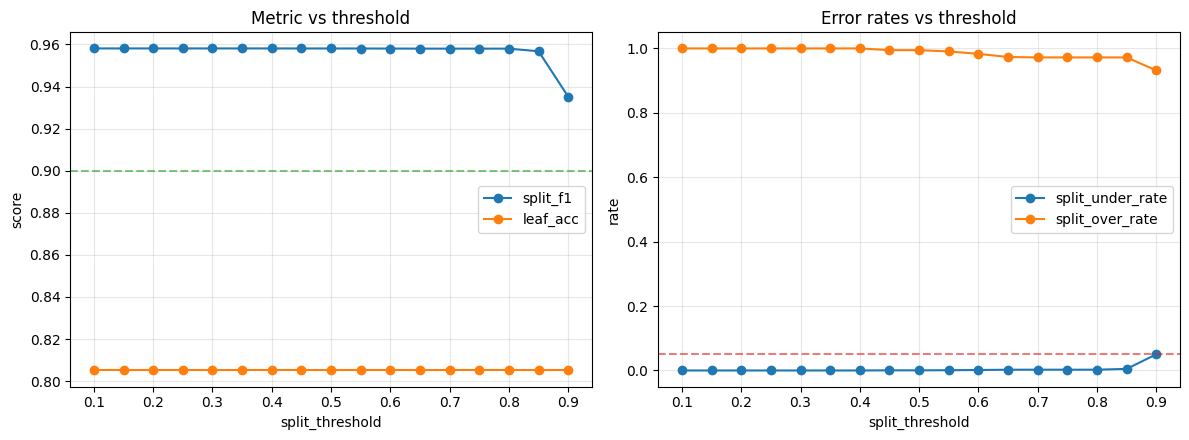

,level,target_split_count,pred_split_count,split_precision,split_recall,split_f1,split_under_rate,split_over_rate,leaf_acc,leaf_node_ratio,variant,hidden,threshold
0,4,12,24,0.500000,1.000000,0.666667,0.000000,1.0,1.000000,0.0,fast,80,0.5
1,3,144,96,1.000000,0.666667,0.800000,0.333333,0.0,1.000000,2.0,fast,80,0.5
2,2,1344,1536,0.875000,1.000000,0.933333,0.000000,1.0,1.000000,0.0,fast,80,0.5
3,1,11787,12288,0.959229,1.000000,0.979190,0.000000,1.0,1.000000,0.0,fast,80,0.5
4,0,90024,98304,0.915771,1.000000,0.956034,0.000000,1.0,0.787319,0.0,fast,80,0.5


In [45]:
plot_threshold_sweep(threshold_frame)

level_confusion = summarize_level_confusion(
    PRIMARY_CHECKPOINT,
    split_threshold=0.5,
    sample_indices=list(range(24)),
)
level_confusion

## Automatic best-threshold finder

Use this cell to score candidate split thresholds by a chosen objective. The default objective is `split_f1_penalized_under`, which maximizes `split_f1` while penalizing thresholds whose `split_under_rate` exceeds a target.

,threshold,split_f1,split_under_rate,split_over_rate,leaf_acc,leaf_node_ratio,variant,hidden,objective,score
0,0.100,0.9581,0.0000,1.0000,0.8050,0.0000,fast,80,split_f1_penalized_under,0.9581
1,0.125,0.9581,0.0000,1.0000,0.8050,0.0000,fast,80,split_f1_penalized_under,0.9581
2,0.150,0.9581,0.0000,1.0000,0.8050,0.0000,fast,80,split_f1_penalized_under,0.9581
3,0.175,0.9580,0.0002,1.0000,0.8050,0.0027,fast,80,split_f1_penalized_under,0.9580
4,0.200,0.9580,0.0002,1.0000,0.8050,0.0027,fast,80,split_f1_penalized_under,0.9580
5,0.225,0.9569,0.0026,0.9978,0.8050,0.0319,fast,80,split_f1_penalized_under,0.9569
6,0.250,0.9563,0.0041,0.9949,0.8050,0.0523,fast,80,split_f1_penalized_under,0.9563
7,0.275,0.9537,0.0096,0.9907,0.8050,0.1196,fast,80,split_f1_penalized_under,0.9537
8,0.300,0.9492,0.0194,0.9775,0.8050,0.2444,fast,80,split_f1_penalized_under,0.9492
9,0.325,0.9404,0.0387,0.9514,0.8050,0.4906,fast,80,split_f1_penalized_under,0.9404


Best threshold = 0.100 for objective='split_f1_penalized_under' with score=0.9581


,threshold,split_f1,split_under_rate,split_over_rate,leaf_acc,leaf_node_ratio,variant,hidden,objective,score
0,0.1,0.958114,0.0,1.0,0.805048,0.0,fast,80,split_f1_penalized_under,0.958114


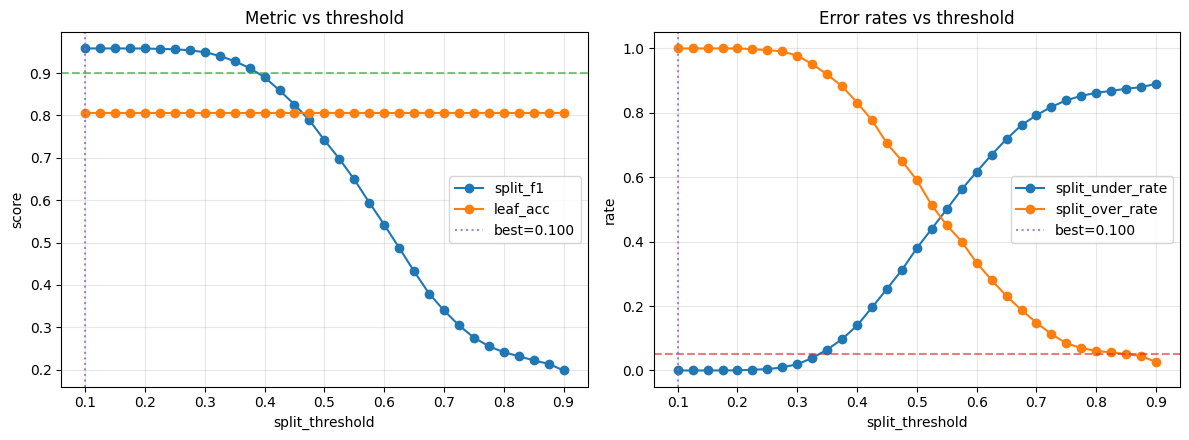

,level,target_split_count,pred_split_count,split_precision,split_recall,split_f1,split_under_rate,split_over_rate,leaf_acc,leaf_node_ratio,variant,hidden,threshold
0,4,12,24,0.500000,1.0,0.666667,0.0,1.0,1.000000,0.0,fast,80,0.1
1,3,144,192,0.750000,1.0,0.857143,0.0,1.0,1.000000,0.0,fast,80,0.1
2,2,1344,1536,0.875000,1.0,0.933333,0.0,1.0,1.000000,0.0,fast,80,0.1
3,1,11787,12288,0.959229,1.0,0.979190,0.0,1.0,1.000000,0.0,fast,80,0.1
4,0,90024,98304,0.915771,1.0,0.956034,0.0,1.0,0.787319,0.0,fast,80,0.1


In [65]:
BEST_THRESHOLD_OBJECTIVE = 'split_f1_penalized_under'
BEST_THRESHOLD_UNDER_PENALTY = 2.0
BEST_THRESHOLD_OVER_PENALTY = 0.0
BEST_THRESHOLD_LEAF_ACC_WEIGHT = 0.0
BEST_THRESHOLD_LEAF_RATIO_PENALTY = 0.0
BEST_THRESHOLD_TARGET_UNDER_RATE = 0.05
BEST_THRESHOLD_GRID = np.linspace(0.10, 0.90, 33)

best_threshold_row, ranked_thresholds = find_best_split_threshold(
    PRIMARY_CHECKPOINT,
    sample_indices=list(range(24)),
    objective=BEST_THRESHOLD_OBJECTIVE,
    under_penalty=BEST_THRESHOLD_UNDER_PENALTY,
    over_penalty=BEST_THRESHOLD_OVER_PENALTY,
    leaf_acc_weight=BEST_THRESHOLD_LEAF_ACC_WEIGHT,
    leaf_ratio_penalty=BEST_THRESHOLD_LEAF_RATIO_PENALTY,
    target_under_rate=BEST_THRESHOLD_TARGET_UNDER_RATE,
    thresholds=BEST_THRESHOLD_GRID,
)

display(
    ranked_thresholds.sort_values('threshold').style.format(
        {
            'threshold': '{:.3f}',
            'split_f1': '{:.4f}',
            'split_under_rate': '{:.4f}',
            'split_over_rate': '{:.4f}',
            'leaf_acc': '{:.4f}',
            'leaf_node_ratio': '{:.4f}',
            'score': '{:.4f}',
        }
    )
)

print(
    f"Best threshold = {float(best_threshold_row['threshold']):.3f} "
    f"for objective={BEST_THRESHOLD_OBJECTIVE!r} with score={float(best_threshold_row['score']):.4f}"
)
display(pd.DataFrame([best_threshold_row]))

plot_threshold_sweep(
    ranked_thresholds,
    best_threshold=float(best_threshold_row['threshold']),
)

best_threshold_level_confusion = summarize_level_confusion(
    PRIMARY_CHECKPOINT,
    split_threshold=float(best_threshold_row['threshold']),
    sample_indices=list(range(24)),
)
best_threshold_level_confusion

## Per-level split-logit calibration diagnostic

Use this section to check whether coarse and fine levels are learning different split-logit distributions. If they are, a single global threshold can look bad even when the model already knows the octree level.

In [66]:
def summarize_split_logit_distributions(
    checkpoint_path: Path,
    *,
    data_path: Path = DATA_PATH,
    sample_indices: list[int] | None = None,
    thresholds: np.ndarray | None = None,
) -> pd.DataFrame:
    if thresholds is None:
        thresholds = np.linspace(0.05, 0.95, 37)

    cfg, cached = _sample_prediction_cache(
        checkpoint_path,
        data_path=data_path,
        sample_indices=sample_indices,
    )

    rows: list[dict[str, Any]] = []
    levels = sorted(cached[0]['levels'].keys(), reverse=True) if cached else []
    threshold_logits = np.array([_threshold_to_logit(float(t)) for t in thresholds], dtype=np.float32)

    for level in levels:
        pos_logits_parts: list[np.ndarray] = []
        neg_logits_parts: list[np.ndarray] = []
        best_threshold = float(thresholds[0])
        best_f1 = float('-inf')
        best_under_rate = float('inf')
        best_over_rate = float('inf')

        for item in cached:
            lvl = item['levels'][level]
            split_logits = lvl['split_logits'].numpy()
            split_tgt = (lvl['target_split'].numpy() > 0.5)
            if split_tgt.any():
                pos_logits_parts.append(split_logits[split_tgt])
            if (~split_tgt).any():
                neg_logits_parts.append(split_logits[~split_tgt])

        pos_logits = np.concatenate(pos_logits_parts) if pos_logits_parts else np.array([], dtype=np.float32)
        neg_logits = np.concatenate(neg_logits_parts) if neg_logits_parts else np.array([], dtype=np.float32)

        tp = np.zeros_like(threshold_logits, dtype=np.float64)
        tn = np.zeros_like(threshold_logits, dtype=np.float64)
        fp = np.zeros_like(threshold_logits, dtype=np.float64)
        fn = np.zeros_like(threshold_logits, dtype=np.float64)

        for item in cached:
            lvl = item['levels'][level]
            split_logits = lvl['split_logits'].numpy()
            split_tgt = (lvl['target_split'].numpy() > 0.5)
            pred = split_logits[None, :] > threshold_logits[:, None]
            tgt = split_tgt[None, :]
            tp += np.sum(pred & tgt, axis=1)
            tn += np.sum((~pred) & (~tgt), axis=1)
            fp += np.sum(pred & (~tgt), axis=1)
            fn += np.sum((~pred) & tgt, axis=1)

        precision = tp / np.maximum(tp + fp, 1.0)
        recall = tp / np.maximum(tp + fn, 1.0)
        f1 = 2.0 * precision * recall / np.maximum(precision + recall, 1e-12)
        under_rate = fn / np.maximum(fn + tp, 1.0)
        over_rate = fp / np.maximum(fp + tn, 1.0)
        best_idx = int(np.argmax(f1))
        best_threshold = float(thresholds[best_idx])
        best_f1 = float(f1[best_idx])
        best_under_rate = float(under_rate[best_idx])
        best_over_rate = float(over_rate[best_idx])

        pos_sigmoid = 1.0 / (1.0 + np.exp(-pos_logits)) if len(pos_logits) else np.array([], dtype=np.float32)
        neg_sigmoid = 1.0 / (1.0 + np.exp(-neg_logits)) if len(neg_logits) else np.array([], dtype=np.float32)

        rows.append(
            {
                'level': level,
                'variant': cfg['model_variant'],
                'hidden': cfg['hidden'],
                'positive_count': int(len(pos_logits)),
                'negative_count': int(len(neg_logits)),
                'positive_logit_mean': float(pos_logits.mean()) if len(pos_logits) else float('nan'),
                'negative_logit_mean': float(neg_logits.mean()) if len(neg_logits) else float('nan'),
                'positive_logit_std': float(pos_logits.std()) if len(pos_logits) else float('nan'),
                'negative_logit_std': float(neg_logits.std()) if len(neg_logits) else float('nan'),
                'positive_prob_mean': float(pos_sigmoid.mean()) if len(pos_sigmoid) else float('nan'),
                'negative_prob_mean': float(neg_sigmoid.mean()) if len(neg_sigmoid) else float('nan'),
                'mean_logit_gap': float(pos_logits.mean() - neg_logits.mean()) if len(pos_logits) and len(neg_logits) else float('nan'),
                'best_level_threshold': best_threshold,
                'best_level_f1': best_f1,
                'best_level_under_rate': best_under_rate,
                'best_level_over_rate': best_over_rate,
            }
        )

    return pd.DataFrame(rows).sort_values('level', ascending=False).reset_index(drop=True)


def plot_split_logit_distributions(
    checkpoint_path: Path,
    *,
    data_path: Path = DATA_PATH,
    sample_indices: list[int] | None = None,
    bins: int = 40,
) -> pd.DataFrame:
    cfg, cached = _sample_prediction_cache(
        checkpoint_path,
        data_path=data_path,
        sample_indices=sample_indices,
    )
    levels = sorted(cached[0]['levels'].keys(), reverse=True) if cached else []
    fig, axes = plt.subplots(len(levels), 2, figsize=(12, 3.2 * max(len(levels), 1)))
    if len(levels) == 1:
        axes = np.expand_dims(axes, axis=0)

    for row_idx, level in enumerate(levels):
        pos_logits_parts: list[np.ndarray] = []
        neg_logits_parts: list[np.ndarray] = []
        for item in cached:
            lvl = item['levels'][level]
            split_logits = lvl['split_logits'].numpy()
            split_tgt = (lvl['target_split'].numpy() > 0.5)
            if split_tgt.any():
                pos_logits_parts.append(split_logits[split_tgt])
            if (~split_tgt).any():
                neg_logits_parts.append(split_logits[~split_tgt])

        pos_logits = np.concatenate(pos_logits_parts) if pos_logits_parts else np.array([], dtype=np.float32)
        neg_logits = np.concatenate(neg_logits_parts) if neg_logits_parts else np.array([], dtype=np.float32)

        ax_logit = axes[row_idx, 0]
        ax_prob = axes[row_idx, 1]

        if len(pos_logits):
            ax_logit.hist(pos_logits, bins=bins, alpha=0.6, density=True, label='target split=1')
            ax_prob.hist(1.0 / (1.0 + np.exp(-pos_logits)), bins=bins, alpha=0.6, density=True, label='target split=1')
        if len(neg_logits):
            ax_logit.hist(neg_logits, bins=bins, alpha=0.6, density=True, label='target split=0')
            ax_prob.hist(1.0 / (1.0 + np.exp(-neg_logits)), bins=bins, alpha=0.6, density=True, label='target split=0')

        ax_logit.axvline(0.0, color='black', linestyle='--', alpha=0.6)
        ax_prob.axvline(0.5, color='black', linestyle='--', alpha=0.6)
        ax_logit.set_title(f'L{level} split logit distribution')
        ax_prob.set_title(f'L{level} split probability distribution')
        ax_logit.set_xlabel('split logit')
        ax_prob.set_xlabel('sigmoid(split logit)')
        ax_logit.set_ylabel('density')
        ax_prob.set_ylabel('density')
        ax_logit.legend()
        ax_prob.legend()
        ax_logit.grid(alpha=0.2)
        ax_prob.grid(alpha=0.2)

    plt.suptitle(f"Per-level split calibration — variant={cfg['model_variant']} hidden={cfg['hidden']}", y=1.02)
    plt.tight_layout()
    plt.show()

    return summarize_split_logit_distributions(
        checkpoint_path,
        data_path=data_path,
        sample_indices=sample_indices,
    )

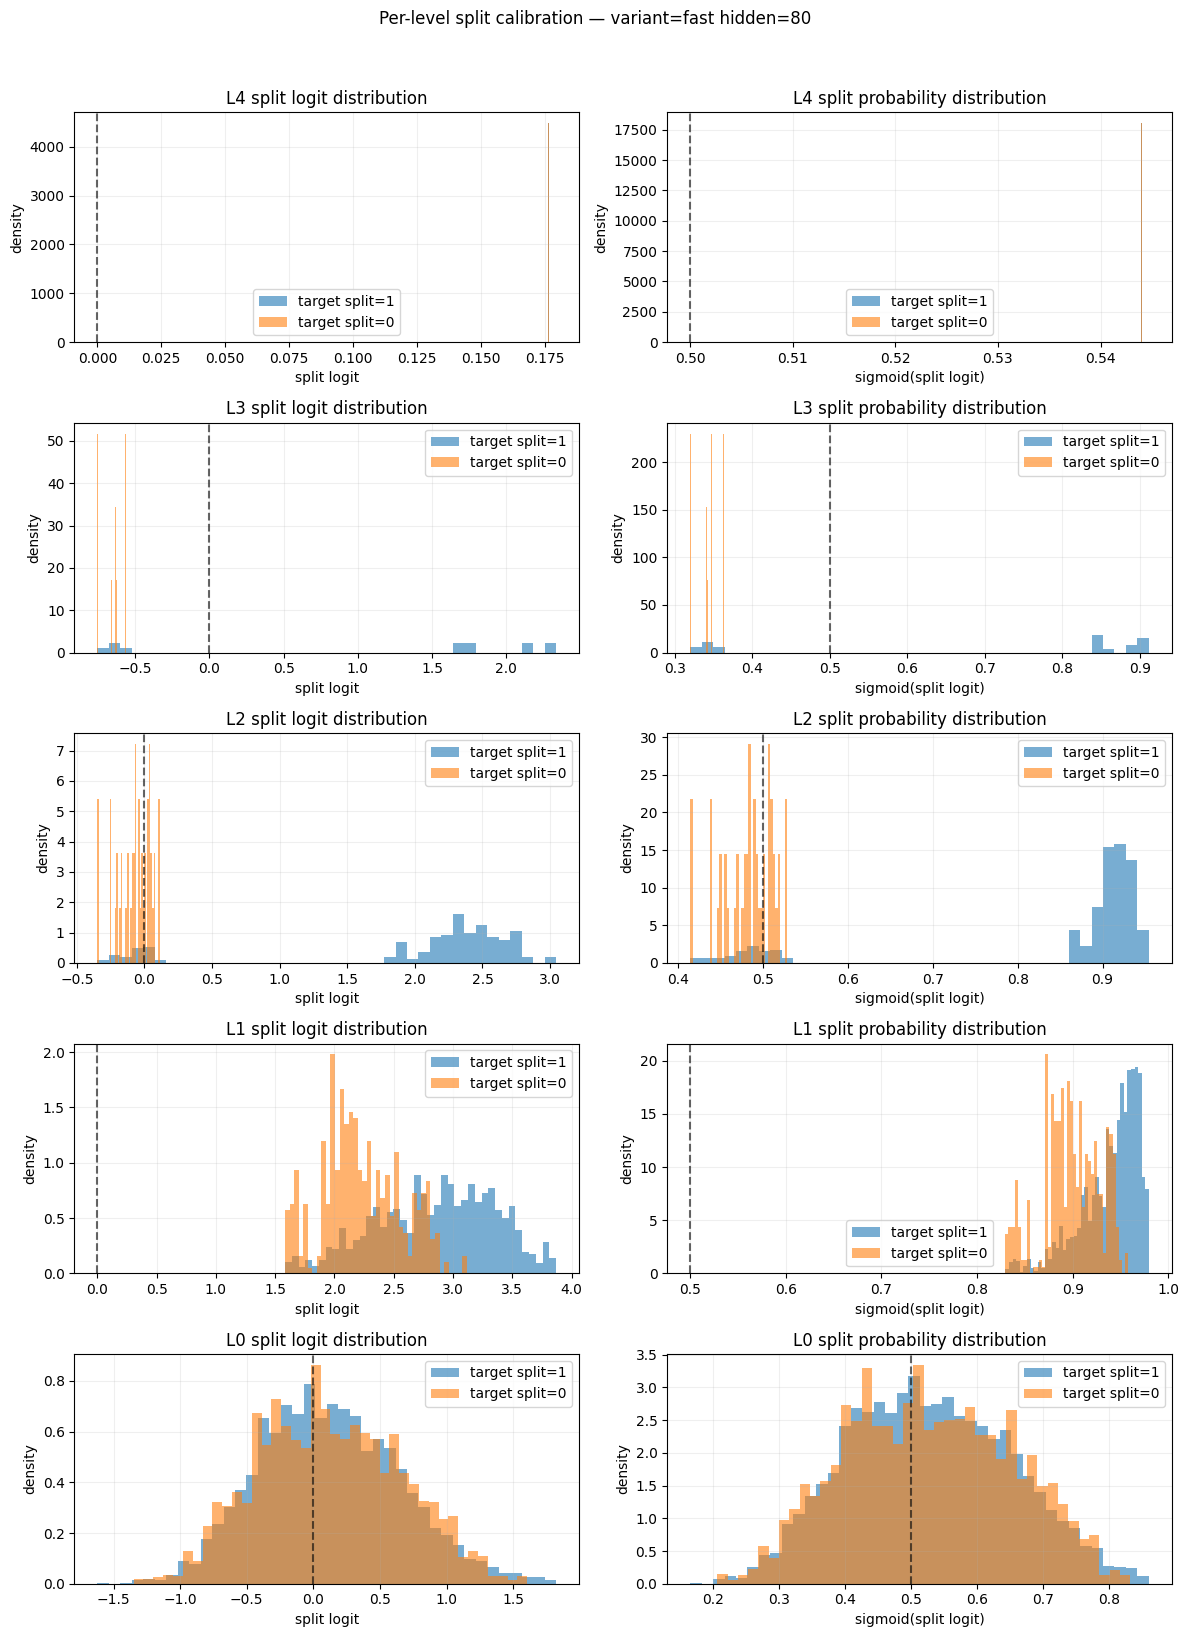

,level,variant,hidden,positive_count,negative_count,positive_logit_mean,negative_logit_mean,positive_logit_std,negative_logit_std,positive_prob_mean,negative_prob_mean,mean_logit_gap,best_level_threshold,best_level_f1,best_level_under_rate,best_level_over_rate
0,4,fast,80,12,12,0.1775,0.1775,0.0013,0.0013,0.5443,0.5443,0.0000,0.050,0.6667,0.0000,1.0000
1,3,fast,80,144,48,1.1022,-0.6523,1.2610,0.0686,0.6980,0.3426,1.7545,0.050,0.8571,0.0000,1.0000
2,2,fast,80,1344,192,2.0405,-0.0686,0.8967,0.1210,0.8524,0.4829,2.1091,0.050,0.9333,0.0000,1.0000
3,1,fast,80,11787,501,2.8547,2.2243,0.4996,0.3322,0.9395,0.8986,0.6304,0.050,0.9792,0.0000,1.0000
4,0,fast,80,90024,8280,0.1218,0.1172,0.5314,0.5369,0.5279,0.5271,0.0046,0.050,0.9560,0.0000,1.0000


,level,variant,hidden,positive_count,negative_count,positive_logit_mean,negative_logit_mean,positive_logit_std,negative_logit_std,positive_prob_mean,negative_prob_mean,mean_logit_gap,best_level_threshold,best_level_f1,best_level_under_rate,best_level_over_rate
0,4,fast,80,12,12,0.177547,0.177547,0.001289,0.001289,0.544270,0.544270,0.000000,0.05,0.666667,0.0,1.0
1,3,fast,80,144,48,1.102248,-0.652267,1.260964,0.068615,0.697991,0.342647,1.754516,0.05,0.857143,0.0,1.0
2,2,fast,80,1344,192,2.040463,-0.068600,0.896659,0.121035,0.852371,0.482942,2.109063,0.05,0.933333,0.0,1.0
3,1,fast,80,11787,501,2.854696,2.224298,0.499594,0.332159,0.939534,0.898558,0.630397,0.05,0.979190,0.0,1.0
4,0,fast,80,90024,8280,0.121762,0.117170,0.531351,0.536943,0.527925,0.527092,0.004591,0.05,0.956034,0.0,1.0


In [67]:
level_logit_frame = plot_split_logit_distributions(
    PRIMARY_CHECKPOINT,
    sample_indices=list(range(24)),
)

display(level_logit_frame.style.format(
    {
        'positive_logit_mean': '{:.4f}',
        'negative_logit_mean': '{:.4f}',
        'positive_logit_std': '{:.4f}',
        'negative_logit_std': '{:.4f}',
        'positive_prob_mean': '{:.4f}',
        'negative_prob_mean': '{:.4f}',
        'mean_logit_gap': '{:.4f}',
        'best_level_threshold': '{:.3f}',
        'best_level_f1': '{:.4f}',
        'best_level_under_rate': '{:.4f}',
        'best_level_over_rate': '{:.4f}',
    }
).background_gradient(subset=['mean_logit_gap', 'best_level_f1'], cmap='Greens').background_gradient(subset=['best_level_under_rate', 'best_level_over_rate'], cmap='Reds_r'))

level_logit_frame

## Per-level threshold policy

Use this section to derive a separate split threshold for each octree level. The default policy below maximizes per-level balanced accuracy on the sampled checkpoint cache, while forcing `L0` to stay leaf (`threshold=1.0`).

In [68]:
def find_per_level_thresholds(
    checkpoint_path: Path,
    *,
    data_path: Path = DATA_PATH,
    sample_indices: list[int] | None = None,
    thresholds: np.ndarray | None = None,
    force_leaf_levels: set[int] | None = None,
) -> tuple[dict[int, float], pd.DataFrame]:
    if thresholds is None:
        thresholds = np.linspace(0.05, 0.95, 37)
    if force_leaf_levels is None:
        force_leaf_levels = {0}

    cfg, cached = _sample_prediction_cache(
        checkpoint_path,
        data_path=data_path,
        sample_indices=sample_indices,
    )
    levels = sorted(cached[0]['levels'].keys(), reverse=True) if cached else []
    threshold_logits = np.array([_threshold_to_logit(float(t)) for t in thresholds], dtype=np.float32)

    rows: list[dict[str, Any]] = []
    threshold_map: dict[int, float] = {}

    for level in levels:
        if level in force_leaf_levels:
            threshold_map[level] = 1.0
            rows.append(
                {
                    'level': level,
                    'threshold': 1.0,
                    'selection_metric': 'forced_leaf',
                    'balanced_acc': float('nan'),
                    'split_f1': float('nan'),
                    'split_under_rate': float('nan'),
                    'split_over_rate': float('nan'),
                    'variant': cfg['model_variant'],
                    'hidden': cfg['hidden'],
                }
            )
            continue

        tp = np.zeros_like(threshold_logits, dtype=np.float64)
        tn = np.zeros_like(threshold_logits, dtype=np.float64)
        fp = np.zeros_like(threshold_logits, dtype=np.float64)
        fn = np.zeros_like(threshold_logits, dtype=np.float64)

        for item in cached:
            lvl = item['levels'][level]
            split_logits = lvl['split_logits'].numpy()
            split_tgt = lvl['target_split'].numpy() > 0.5
            pred = split_logits[None, :] > threshold_logits[:, None]
            tgt = split_tgt[None, :]
            tp += np.sum(pred & tgt, axis=1)
            tn += np.sum((~pred) & (~tgt), axis=1)
            fp += np.sum(pred & (~tgt), axis=1)
            fn += np.sum((~pred) & tgt, axis=1)

        tpr = tp / np.maximum(tp + fn, 1.0)
        tnr = tn / np.maximum(tn + fp, 1.0)
        balanced_acc = 0.5 * (tpr + tnr)
        precision = tp / np.maximum(tp + fp, 1.0)
        recall = tp / np.maximum(tp + fn, 1.0)
        f1 = 2.0 * precision * recall / np.maximum(precision + recall, 1e-12)
        under_rate = fn / np.maximum(fn + tp, 1.0)
        over_rate = fp / np.maximum(fp + tn, 1.0)

        best_idx = int(np.argmax(balanced_acc))
        best_threshold = float(thresholds[best_idx])
        threshold_map[level] = best_threshold
        rows.append(
            {
                'level': level,
                'threshold': best_threshold,
                'selection_metric': 'balanced_acc',
                'balanced_acc': float(balanced_acc[best_idx]),
                'split_f1': float(f1[best_idx]),
                'split_under_rate': float(under_rate[best_idx]),
                'split_over_rate': float(over_rate[best_idx]),
                'variant': cfg['model_variant'],
                'hidden': cfg['hidden'],
            }
        )

    frame = pd.DataFrame(rows).sort_values('level', ascending=False).reset_index(drop=True)
    return threshold_map, frame


def evaluate_threshold_policy(
    checkpoint_path: Path,
    *,
    split_thresholds: dict[int, float],
    data_path: Path = DATA_PATH,
    sample_indices: list[int] | None = None,
) -> dict[str, Any]:
    cfg, cached = _sample_prediction_cache(
        checkpoint_path,
        data_path=data_path,
        sample_indices=sample_indices,
    )

    metric_accum = {
        'split_tp': 0.0,
        'split_tn': 0.0,
        'split_fp': 0.0,
        'split_fn': 0.0,
        'leaf_correct': 0.0,
        'leaf_total': 0.0,
        'pred_leaf_nodes': 0.0,
        'gt_leaf_nodes': 0.0,
    }
    for item in cached:
        converted_preds: dict[int, dict[str, torch.Tensor]] = {}
        converted_targets: dict[int, dict[str, torch.Tensor]] = {}
        for level, lvl in item['levels'].items():
            threshold = float(split_thresholds.get(int(level), 0.5))
            split_pred = (lvl['split_logits'] > _threshold_to_logit(threshold)).float().unsqueeze(0)
            converted_preds[int(level)] = {
                'split': split_pred,
                'label': lvl['label_logits'].unsqueeze(0),
            }
            converted_targets[int(level)] = {
                'split': lvl['target_split'].unsqueeze(0),
                'label': lvl['target_label'].unsqueeze(0),
                'is_leaf': lvl['is_leaf'].unsqueeze(0),
            }
        _update_batch_metrics(converted_preds, converted_targets, metric_accum)

    metrics = _finalize_metrics(metric_accum)
    metrics['variant'] = cfg['model_variant']
    metrics['hidden'] = cfg['hidden']
    metrics['threshold_policy'] = json.dumps({int(k): float(v) for k, v in sorted(split_thresholds.items(), reverse=True)})
    return metrics

In [69]:
PER_LEVEL_THRESHOLD_GRID = np.linspace(0.05, 0.95, 37)

per_level_thresholds, per_level_threshold_frame = find_per_level_thresholds(
    PRIMARY_CHECKPOINT,
    sample_indices=list(range(24)),
    thresholds=PER_LEVEL_THRESHOLD_GRID,
    force_leaf_levels={0},
)

global_050_metrics = evaluate_threshold_policy(
    PRIMARY_CHECKPOINT,
    split_thresholds={4: 0.5, 3: 0.5, 2: 0.5, 1: 0.5, 0: 1.0},
    sample_indices=list(range(24)),
)

global_010_metrics = evaluate_threshold_policy(
    PRIMARY_CHECKPOINT,
    split_thresholds={4: 0.1, 3: 0.1, 2: 0.1, 1: 0.1, 0: 1.0},
    sample_indices=list(range(24)),
)

per_level_policy_metrics = evaluate_threshold_policy(
    PRIMARY_CHECKPOINT,
    split_thresholds=per_level_thresholds,
    sample_indices=list(range(24)),
)

policy_frame = pd.DataFrame([
    {'policy': 'global_0.50_L0_forced_leaf', **global_050_metrics},
    {'policy': 'global_0.10_L0_forced_leaf', **global_010_metrics},
    {'policy': 'per_level_balanced_acc', **per_level_policy_metrics},
])

print('Per-level thresholds:', per_level_thresholds)
display(per_level_threshold_frame.style.format({
    'threshold': '{:.3f}',
    'balanced_acc': '{:.4f}',
    'split_f1': '{:.4f}',
    'split_under_rate': '{:.4f}',
    'split_over_rate': '{:.4f}',
}))

display(policy_frame[[
    'policy', 'split_f1', 'split_under_rate', 'split_over_rate',
    'leaf_acc', 'leaf_node_ratio', 'split_f1_L4', 'split_f1_L3', 'split_f1_L2', 'split_f1_L1', 'split_f1_L0',
    'threshold_policy'
]].style.format({
    'split_f1': '{:.4f}',
    'split_under_rate': '{:.4f}',
    'split_over_rate': '{:.4f}',
    'leaf_acc': '{:.4f}',
    'leaf_node_ratio': '{:.4f}',
    'split_f1_L4': '{:.4f}',
    'split_f1_L3': '{:.4f}',
    'split_f1_L2': '{:.4f}',
    'split_f1_L1': '{:.4f}',
    'split_f1_L0': '{:.4f}',
}))

policy_frame

Per-level thresholds: {4: 0.05, 3: 0.37499999999999994, 2: 0.5499999999999999, 1: 0.9249999999999999, 0: 1.0}


,level,threshold,selection_metric,balanced_acc,split_f1,split_under_rate,split_over_rate,variant,hidden
0,4,0.050,balanced_acc,0.5000,0.6667,0.0000,1.0000,fast,80
1,3,0.375,balanced_acc,0.8333,0.8000,0.3333,0.0000,fast,80
2,2,0.550,balanced_acc,0.9286,0.9231,0.1429,0.0000,fast,80
3,1,0.925,balanced_acc,0.7661,0.8474,0.2583,0.2096,fast,80
4,0,1.000,forced_leaf,nan,nan,nan,nan,fast,80


,policy,split_f1,split_under_rate,split_over_rate,leaf_acc,leaf_node_ratio,split_f1_L4,split_f1_L3,split_f1_L2,split_f1_L1,split_f1_L0,threshold_policy
0,global_0.50_L0_forced_leaf,0.2242,0.8731,0.0643,0.8050,10.9208,0.6667,0.8000,0.9271,0.9792,0.0000,"{""4"": 0.5, ""3"": 0.5, ""2"": 0.5, ""1"": 0.5, ""0"": 1.0}"
1,global_0.10_L0_forced_leaf,0.2264,0.8714,0.0834,0.8050,10.8828,0.6667,0.8571,0.9333,0.9792,0.0000,"{""4"": 0.1, ""3"": 0.1, ""2"": 0.1, ""1"": 0.1, ""0"": 1.0}"
2,per_level_balanced_acc,0.1764,0.9032,0.0130,0.8050,11.3167,0.6667,0.8000,0.9231,0.8474,0.0000,"{""4"": 0.05, ""3"": 0.37499999999999994, ""2"": 0.5499999999999999, ""1"": 0.9249999999999999, ""0"": 1.0}"


,policy,split_acc,split_precision,split_recall,split_f1,split_over_rate,split_under_rate,leaf_acc,leaf_node_ratio,split_f1_L4,split_f1_L3,split_f1_L2,split_f1_L1,split_f1_L0,variant,hidden,threshold_policy
0,global_0.50_L0_forced_leaf,0.191973,0.957579,0.126947,0.224175,0.064320,0.873053,0.805048,10.920846,0.666667,0.800000,0.927052,0.979190,0.0,fast,80,"{""4"": 0.5, ""3"": 0.5, ""2"": 0.5, ""1"": 0.5, ""0"": ..."
1,global_0.10_L0_forced_leaf,0.191973,0.946368,0.128612,0.226449,0.083361,0.871388,0.805048,10.882763,0.666667,0.857143,0.933333,0.979190,0.0,fast,80,"{""4"": 0.1, ""3"": 0.1, ""2"": 0.1, ""1"": 0.1, ""0"": ..."
2,per_level_balanced_acc,0.168402,0.988439,0.096824,0.176372,0.012953,0.903176,0.805048,11.316728,0.666667,0.800000,0.923077,0.847395,0.0,fast,80,"{""4"": 0.05, ""3"": 0.37499999999999994, ""2"": 0.5..."


In [70]:
# Sanity check the policy on a real loader using evaluate_model()
model, dataset, cfg = load_sparse_checkpoint(PRIMARY_CHECKPOINT)
subset_indices = list(range(24))
subset_loader = make_loader(dataset, subset_indices, batch_size=DEFAULTS['batch_size'], shuffle=False)

loader_policy_frame = pd.DataFrame([
    {
        'policy': 'global_0.50_L0_forced_leaf',
        **evaluate_model(
            model,
            subset_loader,
            DEVICE,
            split_weight=1.0,
            label_weight=0.35,
            label_smoothing=0.03,
            split_thresholds={4: 0.5, 3: 0.5, 2: 0.5, 1: 0.5, 0: 1.0},
        ),
    },
    {
        'policy': 'global_0.10_L0_forced_leaf',
        **evaluate_model(
            model,
            subset_loader,
            DEVICE,
            split_weight=1.0,
            label_weight=0.35,
            label_smoothing=0.03,
            split_thresholds={4: 0.1, 3: 0.1, 2: 0.1, 1: 0.1, 0: 1.0},
        ),
    },
    {
        'policy': 'per_level_balanced_acc',
        **evaluate_model(
            model,
            subset_loader,
            DEVICE,
            split_weight=1.0,
            label_weight=0.35,
            label_smoothing=0.03,
            split_thresholds=per_level_thresholds,
        ),
    },
])

loader_policy_frame[['policy', 'loss', 'split_f1', 'split_under_rate', 'split_over_rate', 'leaf_acc', 'leaf_node_ratio']]

,policy,loss,split_f1,split_under_rate,split_over_rate,leaf_acc,leaf_node_ratio
0,global_0.50_L0_forced_leaf,3.533153,0.224175,0.873053,0.064320,0.805048,10.920846
1,global_0.10_L0_forced_leaf,3.533153,0.226449,0.871388,0.083361,0.805048,10.882763
2,per_level_balanced_acc,3.533153,0.176372,0.903176,0.012953,0.805048,11.316728


## Mid-level-only threshold optimization

This pass only optimizes `L3/L2/L1`. `L4` is held fixed, and `L0` is forced to remain a leaf. The goal is to avoid letting root/leaf edge cases dominate the threshold search.

In [71]:
def find_selected_level_thresholds(
    checkpoint_path: Path,
    *,
    optimize_levels: set[int],
    fixed_thresholds: dict[int, float],
    data_path: Path = DATA_PATH,
    sample_indices: list[int] | None = None,
    thresholds: np.ndarray | None = None,
    selection_metric: str = 'balanced_acc',
) -> tuple[dict[int, float], pd.DataFrame]:
    if thresholds is None:
        thresholds = np.linspace(0.05, 0.95, 37)

    cfg, cached = _sample_prediction_cache(
        checkpoint_path,
        data_path=data_path,
        sample_indices=sample_indices,
    )
    levels = sorted(cached[0]['levels'].keys(), reverse=True) if cached else []
    threshold_logits = np.array([_threshold_to_logit(float(t)) for t in thresholds], dtype=np.float32)

    threshold_map = dict(fixed_thresholds)
    rows: list[dict[str, Any]] = []

    for level in levels:
        if level not in optimize_levels:
            rows.append({
                'level': level,
                'threshold': float(threshold_map[level]),
                'selection_metric': 'fixed',
                'balanced_acc': float('nan'),
                'split_f1': float('nan'),
                'split_under_rate': float('nan'),
                'split_over_rate': float('nan'),
                'variant': cfg['model_variant'],
                'hidden': cfg['hidden'],
            })
            continue

        tp = np.zeros_like(threshold_logits, dtype=np.float64)
        tn = np.zeros_like(threshold_logits, dtype=np.float64)
        fp = np.zeros_like(threshold_logits, dtype=np.float64)
        fn = np.zeros_like(threshold_logits, dtype=np.float64)

        for item in cached:
            lvl = item['levels'][level]
            split_logits = lvl['split_logits'].numpy()
            split_tgt = lvl['target_split'].numpy() > 0.5
            pred = split_logits[None, :] > threshold_logits[:, None]
            tgt = split_tgt[None, :]
            tp += np.sum(pred & tgt, axis=1)
            tn += np.sum((~pred) & (~tgt), axis=1)
            fp += np.sum(pred & (~tgt), axis=1)
            fn += np.sum((~pred) & tgt, axis=1)

        tpr = tp / np.maximum(tp + fn, 1.0)
        tnr = tn / np.maximum(tn + fp, 1.0)
        balanced_acc = 0.5 * (tpr + tnr)
        precision = tp / np.maximum(tp + fp, 1.0)
        recall = tp / np.maximum(tp + fn, 1.0)
        f1 = 2.0 * precision * recall / np.maximum(precision + recall, 1e-12)
        under_rate = fn / np.maximum(fn + tp, 1.0)
        over_rate = fp / np.maximum(fp + tn, 1.0)

        if selection_metric == 'split_f1':
            score = f1
        else:
            score = balanced_acc
        best_idx = int(np.argmax(score))
        best_threshold = float(thresholds[best_idx])
        threshold_map[level] = best_threshold
        rows.append({
            'level': level,
            'threshold': best_threshold,
            'selection_metric': selection_metric,
            'balanced_acc': float(balanced_acc[best_idx]),
            'split_f1': float(f1[best_idx]),
            'split_under_rate': float(under_rate[best_idx]),
            'split_over_rate': float(over_rate[best_idx]),
            'variant': cfg['model_variant'],
            'hidden': cfg['hidden'],
        })

    frame = pd.DataFrame(rows).sort_values('level', ascending=False).reset_index(drop=True)
    return threshold_map, frame


mid_level_thresholds, mid_level_threshold_frame = find_selected_level_thresholds(
    PRIMARY_CHECKPOINT,
    optimize_levels={3, 2, 1},
    fixed_thresholds={4: 0.5, 0: 1.0},
    sample_indices=list(range(24)),
    thresholds=PER_LEVEL_THRESHOLD_GRID,
    selection_metric='balanced_acc',
)

mid_level_policy_metrics = evaluate_threshold_policy(
    PRIMARY_CHECKPOINT,
    split_thresholds=mid_level_thresholds,
    sample_indices=list(range(24)),
)

mid_level_compare = pd.DataFrame([
    {'policy': 'global_0.50_L0_forced_leaf', **global_050_metrics},
    {'policy': 'global_0.10_L0_forced_leaf', **global_010_metrics},
    {'policy': 'per_level_balanced_acc', **per_level_policy_metrics},
    {'policy': 'mid_levels_only_balanced_acc', **mid_level_policy_metrics},
])

print('Mid-level thresholds:', mid_level_thresholds)
display(mid_level_threshold_frame.style.format({
    'threshold': '{:.3f}',
    'balanced_acc': '{:.4f}',
    'split_f1': '{:.4f}',
    'split_under_rate': '{:.4f}',
    'split_over_rate': '{:.4f}',
}))

display(mid_level_compare[[
    'policy', 'split_f1', 'split_under_rate', 'split_over_rate',
    'leaf_acc', 'leaf_node_ratio', 'split_f1_L4', 'split_f1_L3', 'split_f1_L2', 'split_f1_L1', 'split_f1_L0',
    'threshold_policy'
]].style.format({
    'split_f1': '{:.4f}',
    'split_under_rate': '{:.4f}',
    'split_over_rate': '{:.4f}',
    'leaf_acc': '{:.4f}',
    'leaf_node_ratio': '{:.4f}',
    'split_f1_L4': '{:.4f}',
    'split_f1_L3': '{:.4f}',
    'split_f1_L2': '{:.4f}',
    'split_f1_L1': '{:.4f}',
    'split_f1_L0': '{:.4f}',
}))

mid_level_compare

Mid-level thresholds: {4: 0.5, 0: 1.0, 3: 0.37499999999999994, 2: 0.5499999999999999, 1: 0.9249999999999999}


,level,threshold,selection_metric,balanced_acc,split_f1,split_under_rate,split_over_rate,variant,hidden
0,4,0.500,fixed,nan,nan,nan,nan,fast,80
1,3,0.375,balanced_acc,0.8333,0.8000,0.3333,0.0000,fast,80
2,2,0.550,balanced_acc,0.9286,0.9231,0.1429,0.0000,fast,80
3,1,0.925,balanced_acc,0.7661,0.8474,0.2583,0.2096,fast,80
4,0,1.000,fixed,nan,nan,nan,nan,fast,80


,policy,split_f1,split_under_rate,split_over_rate,leaf_acc,leaf_node_ratio,split_f1_L4,split_f1_L3,split_f1_L2,split_f1_L1,split_f1_L0,threshold_policy
0,global_0.50_L0_forced_leaf,0.2242,0.8731,0.0643,0.8050,10.9208,0.6667,0.8000,0.9271,0.9792,0.0000,"{""4"": 0.5, ""3"": 0.5, ""2"": 0.5, ""1"": 0.5, ""0"": 1.0}"
1,global_0.10_L0_forced_leaf,0.2264,0.8714,0.0834,0.8050,10.8828,0.6667,0.8571,0.9333,0.9792,0.0000,"{""4"": 0.1, ""3"": 0.1, ""2"": 0.1, ""1"": 0.1, ""0"": 1.0}"
2,per_level_balanced_acc,0.1764,0.9032,0.0130,0.8050,11.3167,0.6667,0.8000,0.9231,0.8474,0.0000,"{""4"": 0.05, ""3"": 0.37499999999999994, ""2"": 0.5499999999999999, ""1"": 0.9249999999999999, ""0"": 1.0}"
3,mid_levels_only_balanced_acc,0.1764,0.9032,0.0130,0.8050,11.3167,0.6667,0.8000,0.9231,0.8474,0.0000,"{""4"": 0.5, ""3"": 0.37499999999999994, ""2"": 0.5499999999999999, ""1"": 0.9249999999999999, ""0"": 1.0}"


,policy,split_acc,split_precision,split_recall,split_f1,split_over_rate,split_under_rate,leaf_acc,leaf_node_ratio,split_f1_L4,split_f1_L3,split_f1_L2,split_f1_L1,split_f1_L0,variant,hidden,threshold_policy
0,global_0.50_L0_forced_leaf,0.191973,0.957579,0.126947,0.224175,0.064320,0.873053,0.805048,10.920846,0.666667,0.800000,0.927052,0.979190,0.0,fast,80,"{""4"": 0.5, ""3"": 0.5, ""2"": 0.5, ""1"": 0.5, ""0"": ..."
1,global_0.10_L0_forced_leaf,0.191973,0.946368,0.128612,0.226449,0.083361,0.871388,0.805048,10.882763,0.666667,0.857143,0.933333,0.979190,0.0,fast,80,"{""4"": 0.1, ""3"": 0.1, ""2"": 0.1, ""1"": 0.1, ""0"": ..."
2,per_level_balanced_acc,0.168402,0.988439,0.096824,0.176372,0.012953,0.903176,0.805048,11.316728,0.666667,0.800000,0.923077,0.847395,0.0,fast,80,"{""4"": 0.05, ""3"": 0.37499999999999994, ""2"": 0.5..."
3,mid_levels_only_balanced_acc,0.168402,0.988439,0.096824,0.176372,0.012953,0.903176,0.805048,11.316728,0.666667,0.800000,0.923077,0.847395,0.0,fast,80,"{""4"": 0.5, ""3"": 0.37499999999999994, ""2"": 0.54..."


## Routing-focused threshold comparison

The aggregate split metrics above still mix in `L0` and can obscure the real routing tradeoff. This section re-scores the same threshold policies using only `L3/L2/L1`, where thresholding actually controls downstream expansion behavior.

In [72]:
def split_policy_score(
    metrics: dict[str, float],
    *,
    under_target: float = 0.05,
    under_penalty: float = 2.0,
    over_penalty: float = 0.5,
) -> float:
    split_f1 = float(metrics.get('split_f1', 0.0) or 0.0)
    split_under_rate = float(metrics.get('split_under_rate', 1.0) or 1.0)
    split_over_rate = float(metrics.get('split_over_rate', 1.0) or 1.0)
    return (
        split_f1
        - under_penalty * max(split_under_rate - under_target, 0.0)
        - over_penalty * split_over_rate
    )


def evaluate_threshold_policy_levels(
    checkpoint_path: Path,
    *,
    split_thresholds: dict[int, float],
    include_levels: set[int],
    data_path: Path = DATA_PATH,
    sample_indices: list[int] | None = None,
) -> dict[str, Any]:
    cfg, cached = _sample_prediction_cache(
        checkpoint_path,
        data_path=data_path,
        sample_indices=sample_indices,
    )

    metric_accum = {
        'split_tp': 0.0,
        'split_tn': 0.0,
        'split_fp': 0.0,
        'split_fn': 0.0,
        'leaf_correct': 0.0,
        'leaf_total': 0.0,
        'pred_leaf_nodes': 0.0,
        'gt_leaf_nodes': 0.0,
    }
    for item in cached:
        converted_preds: dict[int, dict[str, torch.Tensor]] = {}
        converted_targets: dict[int, dict[str, torch.Tensor]] = {}
        for level, lvl in item['levels'].items():
            level_int = int(level)
            if level_int not in include_levels:
                continue
            threshold = float(split_thresholds.get(level_int, 0.5))
            split_pred = (lvl['split_logits'] > _threshold_to_logit(threshold)).float().unsqueeze(0)
            converted_preds[level_int] = {
                'split': split_pred,
                'label': lvl['label_logits'].unsqueeze(0),
            }
            converted_targets[level_int] = {
                'split': lvl['target_split'].unsqueeze(0),
                'label': lvl['target_label'].unsqueeze(0),
                'is_leaf': lvl['is_leaf'].unsqueeze(0),
            }
        if converted_preds:
            _update_batch_metrics(converted_preds, converted_targets, metric_accum)

    metrics = _finalize_metrics(metric_accum)
    metrics['variant'] = cfg['model_variant']
    metrics['hidden'] = cfg['hidden']
    metrics['evaluated_levels'] = json.dumps(sorted(int(level) for level in include_levels), separators=(',', ':'))
    metrics['threshold_policy'] = json.dumps({int(k): float(v) for k, v in sorted(split_thresholds.items(), reverse=True)})
    return metrics


ROUTING_LEVELS = {3, 2, 1}
POLICY_THRESHOLDS = {
    'global_0.50_L0_forced_leaf': {4: 0.5, 3: 0.5, 2: 0.5, 1: 0.5, 0: 1.0},
    'global_0.10_L0_forced_leaf': {4: 0.1, 3: 0.1, 2: 0.1, 1: 0.1, 0: 1.0},
    'per_level_balanced_acc': per_level_thresholds,
    'mid_levels_only_balanced_acc': mid_level_thresholds,
}

routing_rows: list[dict[str, Any]] = []
for policy_name, split_thresholds in POLICY_THRESHOLDS.items():
    full_metrics = evaluate_threshold_policy(
        PRIMARY_CHECKPOINT,
        split_thresholds=split_thresholds,
        sample_indices=list(range(24)),
    )
    routing_metrics = evaluate_threshold_policy_levels(
        PRIMARY_CHECKPOINT,
        split_thresholds=split_thresholds,
        include_levels=ROUTING_LEVELS,
        sample_indices=list(range(24)),
    )
    routing_rows.append(
        {
            'policy': policy_name,
            'full_split_f1': float(full_metrics.get('split_f1', float('nan'))),
            'full_split_under_rate': float(full_metrics.get('split_under_rate', float('nan'))),
            'full_split_over_rate': float(full_metrics.get('split_over_rate', float('nan'))),
            'full_score': split_policy_score(full_metrics),
            'routing_split_f1': float(routing_metrics.get('split_f1', float('nan'))),
            'routing_split_under_rate': float(routing_metrics.get('split_under_rate', float('nan'))),
            'routing_split_over_rate': float(routing_metrics.get('split_over_rate', float('nan'))),
            'routing_score': split_policy_score(routing_metrics),
            'routing_split_f1_L3': float(routing_metrics.get('split_f1_L3', float('nan'))),
            'routing_split_f1_L2': float(routing_metrics.get('split_f1_L2', float('nan'))),
            'routing_split_f1_L1': float(routing_metrics.get('split_f1_L1', float('nan'))),
            'evaluated_levels': routing_metrics['evaluated_levels'],
            'threshold_policy': routing_metrics['threshold_policy'],
        }
    )

routing_policy_frame = pd.DataFrame(routing_rows).sort_values(
    ['routing_score', 'routing_split_f1', 'full_score'],
    ascending=[False, False, False],
).reset_index(drop=True)

display(routing_policy_frame[[
    'policy',
    'routing_score', 'routing_split_f1', 'routing_split_under_rate', 'routing_split_over_rate',
    'routing_split_f1_L3', 'routing_split_f1_L2', 'routing_split_f1_L1',
    'full_score', 'full_split_f1', 'full_split_under_rate', 'full_split_over_rate',
    'evaluated_levels', 'threshold_policy',
]].style.format({
    'routing_score': '{:.4f}',
    'routing_split_f1': '{:.4f}',
    'routing_split_under_rate': '{:.4f}',
    'routing_split_over_rate': '{:.4f}',
    'routing_split_f1_L3': '{:.4f}',
    'routing_split_f1_L2': '{:.4f}',
    'routing_split_f1_L1': '{:.4f}',
    'full_score': '{:.4f}',
    'full_split_f1': '{:.4f}',
    'full_split_under_rate': '{:.4f}',
    'full_split_over_rate': '{:.4f}',
}))

routing_policy_frame

,policy,routing_score,routing_split_f1,routing_split_under_rate,routing_split_over_rate,routing_split_f1_L3,routing_split_f1_L2,routing_split_f1_L1,full_score,full_split_f1,full_split_under_rate,full_split_over_rate,evaluated_levels,threshold_policy
0,global_0.50_L0_forced_leaf,0.5886,0.9725,0.0130,0.7679,0.8000,0.9271,0.9792,-1.4541,0.2242,0.8731,0.0643,"[1,2,3]","{""4"": 0.5, ""3"": 0.5, ""2"": 0.5, ""1"": 0.5, ""0"": 1.0}"
1,per_level_balanced_acc,0.3894,0.8550,0.2474,0.1417,0.8000,0.9231,0.8474,-1.5365,0.1764,0.9032,0.0130,"[1,2,3]","{""4"": 0.05, ""3"": 0.37499999999999994, ""2"": 0.5499999999999999, ""1"": 0.9249999999999999, ""0"": 1.0}"
2,mid_levels_only_balanced_acc,0.3894,0.8550,0.2474,0.1417,0.8000,0.9231,0.8474,-1.5365,0.1764,0.9032,0.0130,"[1,2,3]","{""4"": 0.5, ""3"": 0.37499999999999994, ""2"": 0.5499999999999999, ""1"": 0.9249999999999999, ""0"": 1.0}"
3,global_0.10_L0_forced_leaf,-1.4272,0.9728,0.0000,1.0000,0.8571,0.9333,0.9792,-1.4580,0.2264,0.8714,0.0834,"[1,2,3]","{""4"": 0.1, ""3"": 0.1, ""2"": 0.1, ""1"": 0.1, ""0"": 1.0}"


,policy,full_split_f1,full_split_under_rate,full_split_over_rate,full_score,routing_split_f1,routing_split_under_rate,routing_split_over_rate,routing_score,routing_split_f1_L3,routing_split_f1_L2,routing_split_f1_L1,evaluated_levels,threshold_policy
0,global_0.50_L0_forced_leaf,0.224175,0.873053,0.064320,-1.454092,0.972502,0.012957,0.767881,0.588561,0.800000,0.927052,0.979190,"[1,2,3]","{""4"": 0.5, ""3"": 0.5, ""2"": 0.5, ""1"": 0.5, ""0"": ..."
1,per_level_balanced_acc,0.176372,0.903176,0.012953,-1.536456,0.854991,0.247382,0.141700,0.389376,0.800000,0.923077,0.847395,"[1,2,3]","{""4"": 0.05, ""3"": 0.37499999999999994, ""2"": 0.5..."
2,mid_levels_only_balanced_acc,0.176372,0.903176,0.012953,-1.536456,0.854991,0.247382,0.141700,0.389376,0.800000,0.923077,0.847395,"[1,2,3]","{""4"": 0.5, ""3"": 0.37499999999999994, ""2"": 0.54..."
3,global_0.10_L0_forced_leaf,0.226449,0.871388,0.083361,-1.458008,0.972848,0.000000,1.000000,-1.427152,0.857143,0.933333,0.979190,"[1,2,3]","{""4"": 0.1, ""3"": 0.1, ""2"": 0.1, ""1"": 0.1, ""0"": ..."


## Routing-objective threshold search

This search optimizes thresholds directly against the routing score on `L3/L2/L1` instead of maximizing balanced accuracy independently per level. Because the metric aggregates TP/TN/FP/FN across levels, it can pick a different tradeoff than the per-level sweep above.

In [73]:
def find_best_routing_thresholds(
    checkpoint_path: Path,
    *,
    optimize_levels: tuple[int, ...] = (3, 2, 1),
    include_levels: set[int] | None = None,
    fixed_thresholds: dict[int, float] | None = None,
    data_path: Path = DATA_PATH,
    sample_indices: list[int] | None = None,
    thresholds: np.ndarray | None = None,
    under_target: float = 0.05,
    under_penalty: float = 2.0,
    over_penalty: float = 0.5,
) -> tuple[dict[int, float], pd.DataFrame, dict[str, Any]]:
    if thresholds is None:
        thresholds = np.linspace(0.05, 0.95, 37)
    if include_levels is None:
        include_levels = set(optimize_levels)
    if fixed_thresholds is None:
        fixed_thresholds = {4: 0.5, 0: 1.0}

    cfg, cached = _sample_prediction_cache(
        checkpoint_path,
        data_path=data_path,
        sample_indices=sample_indices,
    )
    threshold_logits = np.array([_threshold_to_logit(float(t)) for t in thresholds], dtype=np.float32)

    per_level_curves: dict[int, dict[str, np.ndarray]] = {}
    fixed_totals = {'tp': 0.0, 'tn': 0.0, 'fp': 0.0, 'fn': 0.0}

    for level in sorted(include_levels, reverse=True):
        tp = np.zeros_like(threshold_logits, dtype=np.float64)
        tn = np.zeros_like(threshold_logits, dtype=np.float64)
        fp = np.zeros_like(threshold_logits, dtype=np.float64)
        fn = np.zeros_like(threshold_logits, dtype=np.float64)

        for item in cached:
            lvl = item['levels'][level]
            split_logits = lvl['split_logits'].numpy()
            split_tgt = lvl['target_split'].numpy() > 0.5
            pred = split_logits[None, :] > threshold_logits[:, None]
            tgt = split_tgt[None, :]
            tp += np.sum(pred & tgt, axis=1)
            tn += np.sum((~pred) & (~tgt), axis=1)
            fp += np.sum(pred & (~tgt), axis=1)
            fn += np.sum((~pred) & tgt, axis=1)

        per_level_curves[level] = {'tp': tp, 'tn': tn, 'fp': fp, 'fn': fn}

        if level not in optimize_levels:
            fixed_threshold = float(fixed_thresholds.get(level, 0.5))
            fixed_idx = int(np.argmin(np.abs(thresholds - fixed_threshold)))
            fixed_totals['tp'] += float(tp[fixed_idx])
            fixed_totals['tn'] += float(tn[fixed_idx])
            fixed_totals['fp'] += float(fp[fixed_idx])
            fixed_totals['fn'] += float(fn[fixed_idx])

    optimize_levels = tuple(level for level in optimize_levels if level in include_levels)
    if not optimize_levels:
        raise ValueError('No optimize_levels overlap with include_levels')

    index_grids = np.meshgrid(*[np.arange(len(thresholds)) for _ in optimize_levels], indexing='ij')
    total_tp = np.full_like(index_grids[0], fixed_totals['tp'], dtype=np.float64)
    total_tn = np.full_like(index_grids[0], fixed_totals['tn'], dtype=np.float64)
    total_fp = np.full_like(index_grids[0], fixed_totals['fp'], dtype=np.float64)
    total_fn = np.full_like(index_grids[0], fixed_totals['fn'], dtype=np.float64)

    for level, idx_grid in zip(optimize_levels, index_grids):
        curves = per_level_curves[level]
        total_tp += curves['tp'][idx_grid]
        total_tn += curves['tn'][idx_grid]
        total_fp += curves['fp'][idx_grid]
        total_fn += curves['fn'][idx_grid]

    precision = total_tp / np.maximum(total_tp + total_fp, 1.0)
    recall = total_tp / np.maximum(total_tp + total_fn, 1.0)
    split_f1 = 2.0 * precision * recall / np.maximum(precision + recall, 1e-12)
    split_under_rate = total_fn / np.maximum(total_fn + total_tp, 1.0)
    split_over_rate = total_fp / np.maximum(total_fp + total_tn, 1.0)
    score = (
        split_f1
        - under_penalty * np.maximum(split_under_rate - under_target, 0.0)
        - over_penalty * split_over_rate
    )

    best_flat_idx = int(np.argmax(score))
    best_multi_idx = np.unravel_index(best_flat_idx, score.shape)

    threshold_map = dict(fixed_thresholds)
    rows: list[dict[str, Any]] = []
    for axis, level in enumerate(optimize_levels):
        chosen_idx = int(best_multi_idx[axis])
        chosen_threshold = float(thresholds[chosen_idx])
        threshold_map[level] = chosen_threshold
        curves = per_level_curves[level]
        tp = float(curves['tp'][chosen_idx])
        tn = float(curves['tn'][chosen_idx])
        fp = float(curves['fp'][chosen_idx])
        fn = float(curves['fn'][chosen_idx])
        precision_lvl = tp / max(tp + fp, 1.0)
        recall_lvl = tp / max(tp + fn, 1.0)
        rows.append(
            {
                'level': level,
                'threshold': chosen_threshold,
                'split_f1': 2.0 * precision_lvl * recall_lvl / max(precision_lvl + recall_lvl, 1e-12),
                'split_under_rate': fn / max(fn + tp, 1.0),
                'split_over_rate': fp / max(fp + tn, 1.0),
                'tp': tp,
                'tn': tn,
                'fp': fp,
                'fn': fn,
                'variant': cfg['model_variant'],
                'hidden': cfg['hidden'],
            }
        )

    for level in sorted(include_levels - set(optimize_levels), reverse=True):
        fixed_threshold = float(fixed_thresholds.get(level, 0.5))
        fixed_idx = int(np.argmin(np.abs(thresholds - fixed_threshold)))
        curves = per_level_curves[level]
        tp = float(curves['tp'][fixed_idx])
        tn = float(curves['tn'][fixed_idx])
        fp = float(curves['fp'][fixed_idx])
        fn = float(curves['fn'][fixed_idx])
        precision_lvl = tp / max(tp + fp, 1.0)
        recall_lvl = tp / max(tp + fn, 1.0)
        rows.append(
            {
                'level': level,
                'threshold': fixed_threshold,
                'split_f1': 2.0 * precision_lvl * recall_lvl / max(precision_lvl + recall_lvl, 1e-12),
                'split_under_rate': fn / max(fn + tp, 1.0),
                'split_over_rate': fp / max(fp + tn, 1.0),
                'tp': tp,
                'tn': tn,
                'fp': fp,
                'fn': fn,
                'variant': cfg['model_variant'],
                'hidden': cfg['hidden'],
                'selection_metric': 'fixed',
            }
        )

    summary = {
        'routing_score': float(score[best_multi_idx]),
        'routing_split_f1': float(split_f1[best_multi_idx]),
        'routing_split_under_rate': float(split_under_rate[best_multi_idx]),
        'routing_split_over_rate': float(split_over_rate[best_multi_idx]),
        'evaluated_levels': json.dumps(sorted(int(level) for level in include_levels), separators=(',', ':')),
        'threshold_policy': json.dumps({int(k): float(v) for k, v in sorted(threshold_map.items(), reverse=True)}),
    }

    frame = pd.DataFrame(rows).sort_values('level', ascending=False).reset_index(drop=True)
    return threshold_map, frame, summary


routing_objective_thresholds, routing_objective_threshold_frame, routing_objective_summary = find_best_routing_thresholds(
    PRIMARY_CHECKPOINT,
    optimize_levels=(3, 2, 1),
    include_levels=ROUTING_LEVELS,
    fixed_thresholds={4: 0.5, 0: 1.0},
    sample_indices=list(range(24)),
    thresholds=PER_LEVEL_THRESHOLD_GRID,
)

POLICY_THRESHOLDS = {
    'global_0.50_L0_forced_leaf': {4: 0.5, 3: 0.5, 2: 0.5, 1: 0.5, 0: 1.0},
    'global_0.10_L0_forced_leaf': {4: 0.1, 3: 0.1, 2: 0.1, 1: 0.1, 0: 1.0},
    'per_level_balanced_acc': per_level_thresholds,
    'mid_levels_only_balanced_acc': mid_level_thresholds,
    'routing_objective': routing_objective_thresholds,
}

routing_rows = []
for policy_name, split_thresholds in POLICY_THRESHOLDS.items():
    full_metrics = evaluate_threshold_policy(
        PRIMARY_CHECKPOINT,
        split_thresholds=split_thresholds,
        sample_indices=list(range(24)),
    )
    routing_metrics = evaluate_threshold_policy_levels(
        PRIMARY_CHECKPOINT,
        split_thresholds=split_thresholds,
        include_levels=ROUTING_LEVELS,
        sample_indices=list(range(24)),
    )
    routing_rows.append(
        {
            'policy': policy_name,
            'full_split_f1': float(full_metrics.get('split_f1', float('nan'))),
            'full_split_under_rate': float(full_metrics.get('split_under_rate', float('nan'))),
            'full_split_over_rate': float(full_metrics.get('split_over_rate', float('nan'))),
            'full_score': split_policy_score(full_metrics),
            'routing_split_f1': float(routing_metrics.get('split_f1', float('nan'))),
            'routing_split_under_rate': float(routing_metrics.get('split_under_rate', float('nan'))),
            'routing_split_over_rate': float(routing_metrics.get('split_over_rate', float('nan'))),
            'routing_score': split_policy_score(routing_metrics),
            'routing_split_f1_L3': float(routing_metrics.get('split_f1_L3', float('nan'))),
            'routing_split_f1_L2': float(routing_metrics.get('split_f1_L2', float('nan'))),
            'routing_split_f1_L1': float(routing_metrics.get('split_f1_L1', float('nan'))),
            'evaluated_levels': routing_metrics['evaluated_levels'],
            'threshold_policy': routing_metrics['threshold_policy'],
        }
    )

routing_policy_frame = pd.DataFrame(routing_rows).sort_values(
    ['routing_score', 'routing_split_f1', 'full_score'],
    ascending=[False, False, False],
).reset_index(drop=True)

print('Routing-objective thresholds:', routing_objective_thresholds)
display(routing_objective_threshold_frame.style.format({
    'threshold': '{:.3f}',
    'split_f1': '{:.4f}',
    'split_under_rate': '{:.4f}',
    'split_over_rate': '{:.4f}',
    'tp': '{:.0f}',
    'tn': '{:.0f}',
    'fp': '{:.0f}',
    'fn': '{:.0f}',
}))

display(routing_policy_frame[[
    'policy',
    'routing_score', 'routing_split_f1', 'routing_split_under_rate', 'routing_split_over_rate',
    'routing_split_f1_L3', 'routing_split_f1_L2', 'routing_split_f1_L1',
    'full_score', 'full_split_f1', 'full_split_under_rate', 'full_split_over_rate',
    'evaluated_levels', 'threshold_policy',
]].style.format({
    'routing_score': '{:.4f}',
    'routing_split_f1': '{:.4f}',
    'routing_split_under_rate': '{:.4f}',
    'routing_split_over_rate': '{:.4f}',
    'routing_split_f1_L3': '{:.4f}',
    'routing_split_f1_L2': '{:.4f}',
    'routing_split_f1_L1': '{:.4f}',
    'full_score': '{:.4f}',
    'full_split_f1': '{:.4f}',
    'full_split_under_rate': '{:.4f}',
    'full_split_over_rate': '{:.4f}',
}))

routing_objective_summary, routing_policy_frame

Routing-objective thresholds: {4: 0.5, 0: 1.0, 3: 0.37499999999999994, 2: 0.5499999999999999, 1: 0.875}


,level,threshold,split_f1,split_under_rate,split_over_rate,tp,tn,fp,fn,variant,hidden
0,3,0.375,0.8000,0.3333,0.0000,96,48,0,48,fast,80
1,2,0.550,0.9231,0.1429,0.0000,1152,192,0,192,fast,80
2,1,0.875,0.9623,0.0408,0.8104,11306,95,406,481,fast,80


,policy,routing_score,routing_split_f1,routing_split_under_rate,routing_split_over_rate,routing_split_f1_L3,routing_split_f1_L2,routing_split_f1_L1,full_score,full_split_f1,full_split_under_rate,full_split_over_rate,evaluated_levels,threshold_policy
0,routing_objective,0.6745,0.9570,0.0543,0.5479,0.8000,0.9231,0.9623,-1.4638,0.2161,0.8784,0.0463,"[1,2,3]","{""4"": 0.5, ""3"": 0.37499999999999994, ""2"": 0.5499999999999999, ""1"": 0.875, ""0"": 1.0}"
1,global_0.50_L0_forced_leaf,0.5886,0.9725,0.0130,0.7679,0.8000,0.9271,0.9792,-1.4541,0.2242,0.8731,0.0643,"[1,2,3]","{""4"": 0.5, ""3"": 0.5, ""2"": 0.5, ""1"": 0.5, ""0"": 1.0}"
2,per_level_balanced_acc,0.3894,0.8550,0.2474,0.1417,0.8000,0.9231,0.8474,-1.5365,0.1764,0.9032,0.0130,"[1,2,3]","{""4"": 0.05, ""3"": 0.37499999999999994, ""2"": 0.5499999999999999, ""1"": 0.9249999999999999, ""0"": 1.0}"
3,mid_levels_only_balanced_acc,0.3894,0.8550,0.2474,0.1417,0.8000,0.9231,0.8474,-1.5365,0.1764,0.9032,0.0130,"[1,2,3]","{""4"": 0.5, ""3"": 0.37499999999999994, ""2"": 0.5499999999999999, ""1"": 0.9249999999999999, ""0"": 1.0}"
4,global_0.10_L0_forced_leaf,-1.4272,0.9728,0.0000,1.0000,0.8571,0.9333,0.9792,-1.4580,0.2264,0.8714,0.0834,"[1,2,3]","{""4"": 0.1, ""3"": 0.1, ""2"": 0.1, ""1"": 0.1, ""0"": 1.0}"


({'routing_score': 0.6744627678419945,
  'routing_split_f1': 0.9570421193062703,
  'routing_split_under_rate': 0.05431261770244821,
  'routing_split_over_rate': 0.5479082321187584,
  'evaluated_levels': '[1,2,3]',
  'threshold_policy': '{"4": 0.5, "3": 0.37499999999999994, "2": 0.5499999999999999, "1": 0.875, "0": 1.0}'},
                          policy  full_split_f1  full_split_under_rate  \
 0             routing_objective       0.216106               0.878367   
 1    global_0.50_L0_forced_leaf       0.224175               0.873053   
 2        per_level_balanced_acc       0.176372               0.903176   
 3  mid_levels_only_balanced_acc       0.176372               0.903176   
 4    global_0.10_L0_forced_leaf       0.226449               0.871388   
 
    full_split_over_rate  full_score  routing_split_f1  \
 0              0.046275   -1.463766          0.957042   
 1              0.064320   -1.454092          0.972502   
 2              0.012953   -1.536456          0.854991  

## Notes

Suggested first-pass gates from the sparse-octree README:
- `split_f1 >= 0.90`
- `split_under_rate <= 0.05`
- `leaf_node_ratio` in `[0.95, 1.10]`
- `leaf_acc >= 0.75`

This notebook uses a notebook-local holdout split because the current sparse trainer optimizes training loss only.

## Structural improvement experiments

This section replaces the retired position-feature ablations. The goal is to test training-side ideas that are more aligned with the current failure modes:
- stronger coarse-level split supervision
- difficulty-aware train/holdout splits
- checkpoint selection by structural score instead of lowest validation loss

The threshold-analysis section above already covers inference-side threshold tuning. The helpers below add training-side probes.

In [49]:
def build_sample_difficulty_frame(npz_path: Path = DATA_PATH) -> pd.DataFrame:
    npz = np.load(npz_path)
    rows: list[dict[str, Any]] = []
    for sample_idx, subchunk in enumerate(npz['subchunk16']):
        subchunk_i32 = subchunk.astype(np.int32)
        targets = build_sparse_octree_targets(subchunk_i32)
        split_count = 0
        leaf_count = 0
        max_level = max(targets)
        for node in iter_sparse_octree_nodes(targets, skip_empty_leaves=False):
            if node.is_leaf or node.child_mask != 0 or node.level == max_level:
                if node.is_leaf:
                    leaf_count += 1
                else:
                    split_count += 1
        air_fraction = float((subchunk_i32 == 0).mean())
        rows.append(
            {
                'sample_idx': sample_idx,
                'air_fraction': air_fraction,
                'solid_fraction': 1.0 - air_fraction,
                'unique_block_ids': int(np.unique(subchunk_i32).size),
                'non_air_blocks': int((subchunk_i32 != 0).sum()),
                'target_split_count': split_count,
                'target_leaf_count': leaf_count,
            }
        )
    frame = pd.DataFrame(rows)
    frame['difficulty_score'] = (
        1.5 * frame['solid_fraction']
        + 1.0 * (frame['target_split_count'] / max(float(frame['target_split_count'].max()), 1.0))
        + 0.5 * (frame['unique_block_ids'] / max(float(frame['unique_block_ids'].max()), 1.0))
    )
    return frame.sort_values('difficulty_score', ascending=False).reset_index(drop=True)


def split_indices_by_difficulty(
    difficulty_frame: pd.DataFrame,
    *,
    holdout_fraction: float,
    seed: int,
    max_samples: int | None = None,
) -> tuple[list[int], list[int]]:
    rng = np.random.default_rng(seed)
    frame = difficulty_frame.copy()
    if max_samples is not None:
        easy = frame[frame['difficulty_score'] < frame['difficulty_score'].quantile(0.33)]
        mid = frame[(frame['difficulty_score'] >= frame['difficulty_score'].quantile(0.33)) & (frame['difficulty_score'] < frame['difficulty_score'].quantile(0.66))]
        hard = frame[frame['difficulty_score'] >= frame['difficulty_score'].quantile(0.66)]
        per_bucket = max(1, max_samples // 3)
        sampled_parts = []
        for bucket in [easy, mid, hard]:
            indices = bucket['sample_idx'].to_numpy()
            rng.shuffle(indices)
            sampled_parts.append(indices[: min(per_bucket, len(indices))])
        chosen = np.concatenate(sampled_parts) if sampled_parts else np.array([], dtype=np.int64)
        if len(chosen) < max_samples:
            remaining = np.setdiff1d(frame['sample_idx'].to_numpy(), chosen, assume_unique=False)
            rng.shuffle(remaining)
            chosen = np.concatenate([chosen, remaining[: max_samples - len(chosen)]])
        frame = frame.set_index('sample_idx').loc[chosen].reset_index()

    order = frame['sample_idx'].to_numpy().copy()
    rng.shuffle(order)
    holdout_count = max(1, int(len(order) * holdout_fraction))
    val_idx = order[:holdout_count].tolist()
    train_idx = order[holdout_count:].tolist()
    if not train_idx:
        raise ValueError('Difficulty split consumed all training samples')
    return train_idx, val_idx


DIFFICULTY_FRAME = build_sample_difficulty_frame(DATA_PATH)
DIFFICULTY_FRAME.head(10)

,sample_idx,air_fraction,solid_fraction,unique_block_ids,non_air_blocks,target_split_count,target_leaf_count,difficulty_score
0,100,0.003418,0.996582,23,4082,396,2773,2.865841
1,101,0.000000,1.000000,30,4096,339,2374,2.839932
2,102,0.032227,0.967773,21,3964,342,2395,2.654006
3,103,0.000000,1.000000,28,4096,261,1828,2.610704
4,97,0.044434,0.955566,19,3914,225,1576,2.307983
5,96,0.204834,0.795166,6,3257,352,2465,2.178412
6,98,0.129639,0.870361,14,3565,238,1667,2.132359
7,99,0.000000,1.000000,19,4096,111,778,2.086755
8,41,0.520752,0.479248,23,1963,269,1884,1.769133
9,40,0.576172,0.423828,22,1736,271,1898,1.674924


In [50]:
def structural_score(
    metrics: dict[str, float],
    *,
    under_target: float = 0.05,
    under_penalty: float = 2.0,
    over_penalty: float = 0.5,
    leaf_ratio_penalty: float = 0.25,
) -> float:
    split_f1 = float(metrics.get('split_f1', 0.0) or 0.0)
    split_under_rate = float(metrics.get('split_under_rate', 1.0) or 1.0)
    split_over_rate = float(metrics.get('split_over_rate', 1.0) or 1.0)
    leaf_node_ratio = float(metrics.get('leaf_node_ratio', 0.0) or 0.0)
    return (
        split_f1
        - under_penalty * max(split_under_rate - under_target, 0.0)
        - over_penalty * split_over_rate
        - leaf_ratio_penalty * abs(leaf_node_ratio - 1.0)
    )


def run_structural_experiment(
    config: ExperimentConfig,
    *,
    split_strategy: str = 'random',
    data_path: Path = DATA_PATH,
    output_dir: Path = OUTPUT_DIR,
    device: str = DEVICE,
) -> dict[str, Any]:
    set_seed(config.seed)
    dataset = SparseOctreeDataset(data_path, cache_targets=config.cache_targets)
    if split_strategy == 'difficulty_stratified':
        train_idx, val_idx = split_indices_by_difficulty(
            DIFFICULTY_FRAME,
            holdout_fraction=config.holdout_fraction,
            seed=config.seed,
            max_samples=config.max_samples,
        )
    elif split_strategy == 'random':
        train_idx, val_idx = split_indices(
            len(dataset),
            holdout_fraction=config.holdout_fraction,
            seed=config.seed,
            max_samples=config.max_samples,
        )
    else:
        raise ValueError(f'Unknown split_strategy={split_strategy!r}')

    train_loader = make_loader(dataset, train_idx, config.batch_size, shuffle=True)
    val_loader = make_loader(dataset, val_idx, config.batch_size, shuffle=False)

    sample = dataset[train_idx[0]]
    model = _build_model(
        config.model_variant,
        n2d=int(sample['noise_2d'].shape[0]),
        n3d=int(sample['noise_3d'].shape[0]),
        hidden=config.hidden,
        num_classes=config.num_classes,
        spatial_y=int(dataset.spatial_y),
    ).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=config.lr)
    max_level = int(getattr(model, 'max_level', 4))
    default_level_split_weights, default_level_label_weights = _default_level_weights(max_level)
    level_split_weights = dict(default_level_split_weights)
    level_label_weights = dict(default_level_label_weights)
    if config.level_split_weights:
        level_split_weights.update(config.level_split_weights)
    if config.level_label_weights:
        level_label_weights.update(config.level_label_weights)

    best_score = float('-inf')
    best_epoch = -1
    best_state = None
    best_val_metrics = None
    history: list[dict[str, float]] = []

    for epoch in range(1, config.epochs + 1):
        model.train()
        total_loss = 0.0
        total_batches = 0
        metric_accum = {
            'split_tp': 0.0,
            'split_tn': 0.0,
            'split_fp': 0.0,
            'split_fn': 0.0,
            'leaf_correct': 0.0,
            'leaf_total': 0.0,
            'pred_leaf_nodes': 0.0,
            'gt_leaf_nodes': 0.0,
        }
        for batch in train_loader:
            noise_2d = batch['noise_2d'].to(device)
            noise_3d = batch['noise_3d'].to(device)
            biome_ids = batch['biome_ids'].to(device)
            heightmap_surface = batch['heightmap_surface'].to(device)
            heightmap_ocean_floor = batch['heightmap_ocean_floor'].to(device)
            optimizer.zero_grad()
            preds = model(
                noise_2d,
                noise_3d,
                biome_ids,
                heightmap_surface,
                heightmap_ocean_floor,
            )
            loss = _sparse_octree_loss(
                preds,
                batch['targets'],
                split_weight=config.split_weight,
                label_weight=config.label_weight,
                level_split_weights=level_split_weights,
                level_label_weights=level_label_weights,
                label_smoothing=config.label_smoothing,
                dynamic_split_pos_weight=True,
            )
            loss.backward()
            optimizer.step()
            total_loss += float(loss.detach().cpu())
            total_batches += 1
            _update_batch_metrics(preds, batch['targets'], metric_accum)

        train_metrics = {'loss': total_loss / max(total_batches, 1)}
        train_metrics.update(_finalize_metrics(metric_accum))
        val_metrics = evaluate_model(
            model,
            val_loader,
            device,
            split_weight=config.split_weight,
            label_weight=config.label_weight,
            label_smoothing=config.label_smoothing,
            level_split_weights=level_split_weights,
            level_label_weights=level_label_weights,
        )
        score = structural_score(val_metrics)

        row = {'epoch': float(epoch), 'val_structural_score': float(score)}
        row.update({f'train_{k}': float(v) for k, v in train_metrics.items()})
        row.update({f'val_{k}': float(v) for k, v in val_metrics.items()})
        history.append(row)

        if score > best_score:
            best_score = float(score)
            best_epoch = epoch
            best_val_metrics = dict(val_metrics)
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    checkpoint_path = output_dir / f'{config.name}_{split_strategy}.pt'
    torch.save(best_state if best_state is not None else model.state_dict(), checkpoint_path)
    return {
        'name': config.name,
        'config': {**asdict(config), 'split_strategy': split_strategy},
        'checkpoint': str(checkpoint_path),
        'train_samples': len(train_idx),
        'val_samples': len(val_idx),
        'best_epoch': best_epoch,
        'best_structural_score': best_score,
        'best_val_metrics': best_val_metrics,
        'history': history,
    }

In [51]:
RUN_STRUCTURAL_SWEEP = False

if RUN_STRUCTURAL_SWEEP:
    structural_results = [
        run_structural_experiment(
            ExperimentConfig(
                name='fast_h64_random_baseline_e100',
                hidden=64,
                model_variant='fast',
                max_samples=256,
                epochs=100,
            ),
            split_strategy='random',
        ),
        run_structural_experiment(
            ExperimentConfig(
                name='fast_h64_coarse_split_upweight_e100',
                hidden=64,
                model_variant='fast',
                max_samples=256,
                epochs=100,
                level_split_weights={4: 3.0, 3: 2.25, 2: 1.5},
            ),
            split_strategy='random',
        ),
        run_structural_experiment(
            ExperimentConfig(
                name='fast_h64_difficulty_stratified_e100',
                hidden=64,
                model_variant='fast',
                max_samples=256,
                epochs=100,
            ),
            split_strategy='difficulty_stratified',
        ),
    ]

    structural_frame = pd.DataFrame([
        {
            'name': r['name'],
            'split_strategy': r['config']['split_strategy'],
            'hidden': r['config']['hidden'],
            'epochs': r['config']['epochs'],
            'best_epoch': r['best_epoch'],
            'best_structural_score': r['best_structural_score'],
            'val_loss': r['best_val_metrics']['loss'],
            'split_f1': r['best_val_metrics']['split_f1'],
            'split_under_rate': r['best_val_metrics']['split_under_rate'],
            'split_over_rate': r['best_val_metrics']['split_over_rate'],
            'leaf_acc': r['best_val_metrics']['leaf_acc'],
            'leaf_node_ratio': r['best_val_metrics']['leaf_node_ratio'],
        }
        for r in structural_results
    ]).sort_values(['best_structural_score', 'split_f1'], ascending=[False, False])

    display(structural_frame)
    save_results(structural_results)
else:
    print('Set RUN_STRUCTURAL_SWEEP = True to compare baseline, coarse-split-upweight, and difficulty-stratified training.')

Set RUN_STRUCTURAL_SWEEP = True to compare baseline, coarse-split-upweight, and difficulty-stratified training.
